In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

ds = load_dataset("lukebarousse/data_jobs")

print("Dataset berhasil dimuat.")
print(ds)

df_jobs = ds["train"].to_pandas()

print("\nUkuran data:")
print(f"{df_jobs.shape[0]:,} baris dan {df_jobs.shape[1]} kolom")

print("\nDaftar kolom:")
print(df_jobs.columns.tolist())

df_jobs.head()

README.md:   0%|          | 0.00/3.25k [00:00<?, ?B/s]

data_jobs.csv:   0%|          | 0.00/231M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/785741 [00:00<?, ? examples/s]

Dataset berhasil dimuat.
DatasetDict({
    train: Dataset({
        features: ['job_title_short', 'job_title', 'job_location', 'job_via', 'job_schedule_type', 'job_work_from_home', 'search_location', 'job_posted_date', 'job_no_degree_mention', 'job_health_insurance', 'job_country', 'salary_rate', 'salary_year_avg', 'salary_hour_avg', 'company_name', 'job_skills', 'job_type_skills'],
        num_rows: 785741
    })
})

Ukuran data:
785,741 baris dan 17 kolom

Daftar kolom:
['job_title_short', 'job_title', 'job_location', 'job_via', 'job_schedule_type', 'job_work_from_home', 'search_location', 'job_posted_date', 'job_no_degree_mention', 'job_health_insurance', 'job_country', 'salary_rate', 'salary_year_avg', 'salary_hour_avg', 'company_name', 'job_skills', 'job_type_skills']


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clinical Data Engineer ...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 'tableau']","{'analyst_tools': ['power bi', 'tableau'], 'programming': ['r', 'python', 'sql', 'nosql']}"
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior (m/f/x)","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'dax', 'docker', 'kubernetes', 'jenkins']","{'analyst_tools': ['dax'], 'cloud': ['azure'], 'libraries': ['airflow'], 'other': ['docker', 'kubernetes', 'jenkins'..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ENGINEER - DATA...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'tensorflow', 'keras', 'pytorch']","{'cloud': ['aws'], 'libraries': ['tensorflow', 'keras', 'pytorch'], 'programming': ['python', 'c++', 'java', 'matlab']}"
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,None,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible', 'puppet', 'jenkins', 'gitlab', 'git']","{'cloud': ['oracle', 'aws'], 'other': ['ansible', 'puppet', 'jenkins', 'gitlab', 'git'], 'programming': ['bash', 'py..."


In [2]:
# Cek struktur data dan kualitas awal

print("=" * 60)
print("INFO DATA")
print("=" * 60)

print(f"Jumlah baris : {df_jobs.shape[0]:,}")
print(f"Jumlah kolom : {df_jobs.shape[1]}")

print("\nTipe data setiap kolom:")
display(df_jobs.dtypes.reset_index().rename(columns={"index": "column", 0: "data_type"}))


print("\n" + "=" * 60)
print("MISSING VALUE")
print("=" * 60)

missing_summary = pd.DataFrame({
    "missing_count": df_jobs.isna().sum(),
    "missing_percentage": (df_jobs.isna().mean() * 100).round(2)
}).sort_values("missing_percentage", ascending=False)

display(missing_summary)


print("\n" + "=" * 60)
print("JUMLAH DATA UNIK")
print("=" * 60)

unique_summary = pd.DataFrame({
    "unique_count": df_jobs.nunique()
}).sort_values("unique_count", ascending=False)

display(unique_summary)


print("\n" + "=" * 60)
print("ROLE PEKERJAAN YANG TERSEDIA")
print("=" * 60)

role_counts = df_jobs["job_title_short"].value_counts().reset_index()
role_counts.columns = ["job_title_short", "total"]

display(role_counts)


print("\n" + "=" * 60)
print("CONTOH DATA SKILL")
print("=" * 60)

sample_skills = df_jobs[
    df_jobs["job_skills"].notna()
][["job_title_short", "job_title", "job_country", "salary_year_avg", "job_work_from_home", "job_skills"]].head(10)

display(sample_skills)

INFO DATA
Jumlah baris : 785,741
Jumlah kolom : 17

Tipe data setiap kolom:


,column,data_type
0,job_title_short,object
1,job_title,object
2,job_location,object
3,job_via,object
4,job_schedule_type,object
5,job_work_from_home,bool
6,search_location,object
7,job_posted_date,object
8,job_no_degree_mention,bool
9,job_health_insurance,bool



MISSING VALUE


,missing_count,missing_percentage
salary_hour_avg,775079,98.64
salary_year_avg,763738,97.20
salary_rate,752674,95.79
job_type_skills,117037,14.90
job_skills,117037,14.90
job_schedule_type,12667,1.61
job_location,1045,0.13
job_country,49,0.01
job_title_short,0,0.00
job_no_degree_mention,0,0.00



JUMLAH DATA UNIK


,unique_count
job_posted_date,607192
job_title,234673
job_type_skills,177562
job_skills,177562
company_name,139982
job_location,17217
job_via,7903
salary_year_avg,2702
salary_hour_avg,1184
search_location,173



ROLE PEKERJAAN YANG TERSEDIA


,job_title_short,total
0,Data Analyst,196075
1,Data Engineer,186241
2,Data Scientist,172286
3,Business Analyst,49063
4,Software Engineer,44929
5,Senior Data Engineer,44563
6,Senior Data Scientist,36957
7,Senior Data Analyst,29216
8,Machine Learning Engineer,14080
9,Cloud Engineer,12331



CONTOH DATA SKILL


,job_title_short,job_title,job_country,salary_year_avg,job_work_from_home,job_skills
1,Data Analyst,Data Analyst,Mexico,NaN,False,"['r', 'python', 'sql', 'nosql', 'power bi', 'tableau']"
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior (m/f/x)",Germany,NaN,False,"['python', 'sql', 'c#', 'azure', 'airflow', 'dax', 'docker', 'kubernetes', 'jenkins']"
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ENGINEER - DATA...,United States,NaN,False,"['python', 'c++', 'java', 'matlab', 'aws', 'tensorflow', 'keras', 'pytorch']"
4,Data Engineer,Data Engineer- Sr Jobs,Sudan,NaN,False,"['bash', 'python', 'oracle', 'aws', 'ansible', 'puppet', 'jenkins', 'gitlab', 'git']"
5,Data Engineer,GCP Data Engineer,United States,NaN,True,"['python', 'sql', 'gcp']"
6,Senior Data Engineer,Senior Data Engineer - GCP Cloud,United States,NaN,False,"['sql', 'python', 'java', 'sql server', 'gcp', 'bigquery', 'hadoop']"
7,Data Engineer,Data Engineer,Romania,NaN,True,"['sql', 'nosql', 'gcp', 'azure', 'aws', 'bigquery', 'databricks', 'redshift', 'airflow', 'kafka', 'spark']"
8,Business Analyst,Technology & Operations Business Analyst,Denmark,NaN,False,"['excel', 'powerpoint', 'power bi']"
9,Data Scientist,Data Scientist II,United States,NaN,True,"['sql', 'python', 'r', 'mongodb', 'mongodb', 'sql server', 'azure', 'pandas', 'spark', 'windows', 'excel']"
10,Data Engineer,Erfahrene*r Data Engineer*in (m/w/d),Switzerland,NaN,False,"['python', 'databricks', 'azure', 'spark']"


In [3]:
import ast

df_clean = df_jobs.copy()

# Ubah tanggal posting jadi format datetime
df_clean["job_posted_date"] = pd.to_datetime(df_clean["job_posted_date"], errors="coerce")

# Ambil tahun dan bulan posting
df_clean["posted_year"] = df_clean["job_posted_date"].dt.year
df_clean["posted_month"] = df_clean["job_posted_date"].dt.to_period("M").astype(str)

# Bikin label remote yang lebih enak dibaca
df_clean["work_type"] = df_clean["job_work_from_home"].map({
    True: "Work From Home",
    False: "On-site / Not Mentioned"
})

# Fungsi buat merapikan isi kolom job_skills
def clean_skill_list(skills):
    if skills is None:
        return []

    if isinstance(skills, float) and pd.isna(skills):
        return []

    if isinstance(skills, list):
        skill_list = skills

    elif isinstance(skills, str):
        try:
            skill_list = ast.literal_eval(skills)
        except:
            skill_list = [skills]

    else:
        return []

    # Rapihin teks skill dan hilangkan duplikat dalam satu job posting
    cleaned = []
    for skill in skill_list:
        skill = str(skill).strip().lower()
        if skill and skill not in cleaned:
            cleaned.append(skill)

    return cleaned

# Terapkan ke dataframe
df_clean["skills_clean"] = df_clean["job_skills"].apply(clean_skill_list)

# Data job posting yang punya skill
df_with_skills = df_clean[df_clean["skills_clean"].apply(len) > 0].copy()

# Pecah skill: satu baris = satu skill dari satu job posting
df_skills = df_with_skills.explode("skills_clean").copy()
df_skills = df_skills.rename(columns={"skills_clean": "skill"})

# Ringkasan hasil cleaning
print("Ringkasan data setelah cleaning")
print("-" * 50)
print(f"Total job posting awal              : {df_jobs.shape[0]:,}")
print(f"Job posting yang punya data skill   : {df_with_skills.shape[0]:,}")
print(f"Total baris setelah skill dipecah   : {df_skills.shape[0]:,}")
print(f"Jumlah skill unik                   : {df_skills['skill'].nunique():,}")

print("\nContoh data skill yang sudah dipecah:")
display(
    df_skills[
        ["job_title_short", "job_title", "job_country", "work_type", "salary_year_avg", "skill"]
    ].head(15)
)

print("\nTop 20 skill paling sering muncul:")
display(
    df_skills["skill"]
    .value_counts()
    .head(20)
    .reset_index()
    .rename(columns={"index": "skill", "skill": "total"})
)

Ringkasan data setelah cleaning
--------------------------------------------------
Total job posting awal              : 785,741
Job posting yang punya data skill   : 668,704
Total baris setelah skill dipecah   : 3,594,898
Jumlah skill unik                   : 252

Contoh data skill yang sudah dipecah:


,job_title_short,job_title,job_country,work_type,salary_year_avg,skill
1,Data Analyst,Data Analyst,Mexico,On-site / Not Mentioned,NaN,r
1,Data Analyst,Data Analyst,Mexico,On-site / Not Mentioned,NaN,python
1,Data Analyst,Data Analyst,Mexico,On-site / Not Mentioned,NaN,sql
1,Data Analyst,Data Analyst,Mexico,On-site / Not Mentioned,NaN,nosql
1,Data Analyst,Data Analyst,Mexico,On-site / Not Mentioned,NaN,power bi
1,Data Analyst,Data Analyst,Mexico,On-site / Not Mentioned,NaN,tableau
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior (m/f/x)",Germany,On-site / Not Mentioned,NaN,python
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior (m/f/x)",Germany,On-site / Not Mentioned,NaN,sql
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior (m/f/x)",Germany,On-site / Not Mentioned,NaN,c#
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior (m/f/x)",Germany,On-site / Not Mentioned,NaN,azure



Top 20 skill paling sering muncul:


,total,count
0,sql,384849
1,python,380909
2,aws,145381
3,azure,132527
4,r,130892
5,tableau,127213
6,excel,127018
7,spark,114609
8,power bi,98147
9,java,85612


Top 15 skill paling banyak dicari perusahaan


,skill,total_mentions,percentage
204,sql,384849,57.55
167,python,380909,56.96
15,aws,145381,21.74
16,azure,132527,19.82
171,r,130892,19.57
217,tableau,127213,19.02
63,excel,127018,18.99
199,spark,114609,17.14
160,power bi,98147,14.68
97,java,85612,12.80



Visualisasi: Skill paling banyak dicari perusahaan


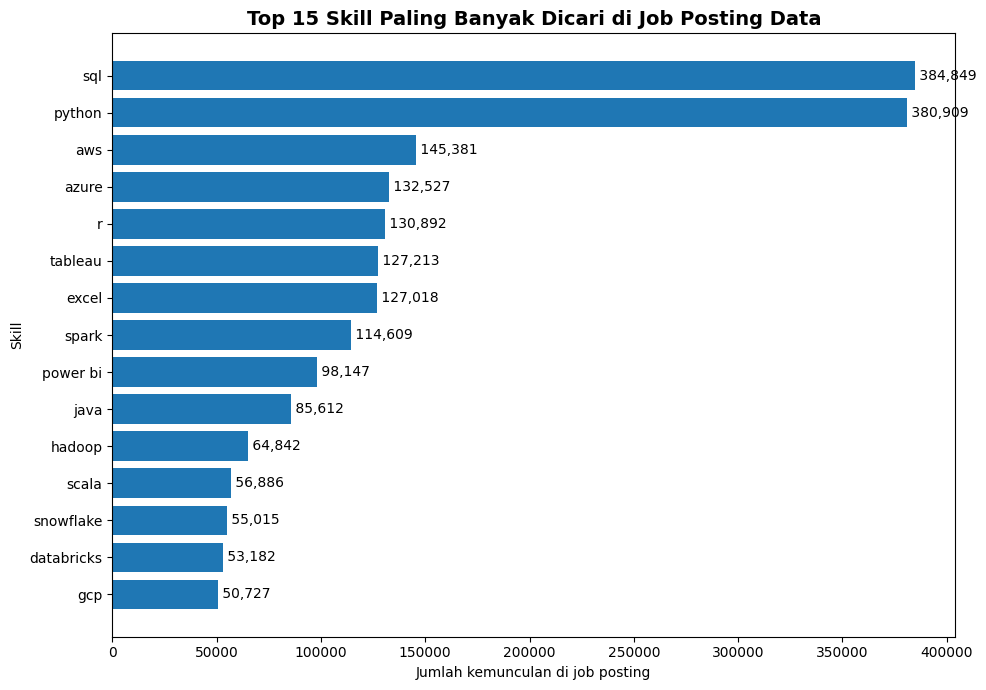

In [4]:
# Analisis skill paling banyak dicari secara umum

import matplotlib.pyplot as plt

total_jobs_with_skills = df_with_skills.shape[0]

top_skills = (
    df_skills
    .groupby("skill")
    .size()
    .reset_index(name="total_mentions")
    .sort_values("total_mentions", ascending=False)
    .head(15)
)

top_skills["percentage"] = (
    top_skills["total_mentions"] / total_jobs_with_skills * 100
).round(2)

print("=" * 70)
print("Top 15 skill paling banyak dicari perusahaan")
print("=" * 70)

display(top_skills)


print("\n" + "=" * 70)
print("Visualisasi: Skill paling banyak dicari perusahaan")
print("=" * 70)

plt.figure(figsize=(10, 7))

plt.barh(
    top_skills["skill"][::-1],
    top_skills["total_mentions"][::-1]
)

plt.title("Top 15 Skill Paling Banyak Dicari di Job Posting Data", fontsize=14, fontweight="bold")
plt.xlabel("Jumlah kemunculan di job posting")
plt.ylabel("Skill")

for index, value in enumerate(top_skills["total_mentions"][::-1]):
    plt.text(value, index, f" {value:,}", va="center")

plt.tight_layout()
plt.show()

Top 15 skill paling banyak dicari untuk Data Analyst
Total job posting Data Analyst yang punya data skill: 159,394


,skill,total_mentions,percentage
189,sql,92428,57.99
58,excel,66860,41.95
154,python,57190,35.88
202,tableau,46455,29.14
147,power bi,39380,24.71
158,r,29996,18.82
170,sas,13999,8.78
149,powerpoint,13822,8.67
228,word,13562,8.51
169,sap,11280,7.08



Visualisasi: Skill paling banyak dicari untuk Data Analyst


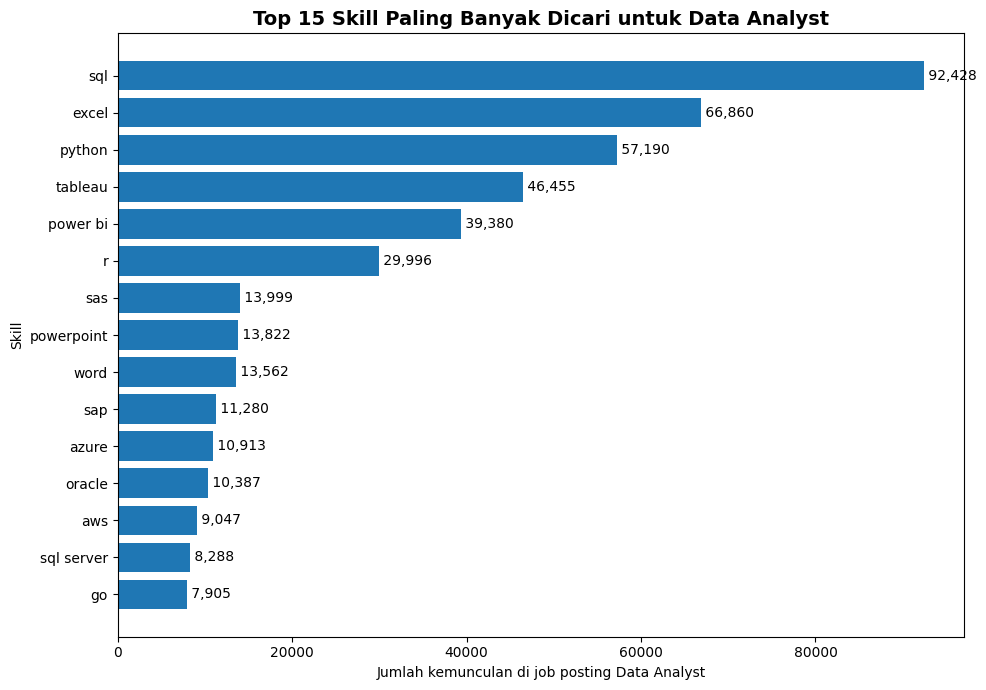

In [5]:
# Skill paling dicari untuk role Data Analyst

data_analyst_jobs = df_with_skills[
    df_with_skills["job_title_short"] == "Data Analyst"
].copy()

data_analyst_skills = df_skills[
    df_skills["job_title_short"] == "Data Analyst"
].copy()

total_data_analyst_jobs = data_analyst_jobs.shape[0]

top_da_skills = (
    data_analyst_skills
    .groupby("skill")
    .size()
    .reset_index(name="total_mentions")
    .sort_values("total_mentions", ascending=False)
    .head(15)
)

top_da_skills["percentage"] = (
    top_da_skills["total_mentions"] / total_data_analyst_jobs * 100
).round(2)

print("=" * 70)
print("Top 15 skill paling banyak dicari untuk Data Analyst")
print("=" * 70)

print(f"Total job posting Data Analyst yang punya data skill: {total_data_analyst_jobs:,}")
display(top_da_skills)


print("\n" + "=" * 70)
print("Visualisasi: Skill paling banyak dicari untuk Data Analyst")
print("=" * 70)

plt.figure(figsize=(10, 7))

plt.barh(
    top_da_skills["skill"][::-1],
    top_da_skills["total_mentions"][::-1]
)

plt.title("Top 15 Skill Paling Banyak Dicari untuk Data Analyst", fontsize=14, fontweight="bold")
plt.xlabel("Jumlah kemunculan di job posting Data Analyst")
plt.ylabel("Skill")

for index, value in enumerate(top_da_skills["total_mentions"][::-1]):
    plt.text(value, index, f" {value:,}", va="center")

plt.tight_layout()
plt.show()

Top 10 skill paling dicari untuk setiap role


,job_title_short,skill,total_mentions,total_jobs,percentage
0,Data Analyst,sql,92428,159394,57.99
1,Data Analyst,excel,66860,159394,41.95
2,Data Analyst,python,57190,159394,35.88
3,Data Analyst,tableau,46455,159394,29.14
4,Data Analyst,power bi,39380,159394,24.71
5,Data Analyst,r,29996,159394,18.82
6,Data Analyst,sas,13999,159394,8.78
7,Data Analyst,powerpoint,13822,159394,8.67
8,Data Analyst,word,13562,159394,8.51
9,Data Analyst,sap,11280,159394,7.08



Matriks persentase skill berdasarkan role


job_title_short,Data Analyst,Data Scientist,Data Engineer,Machine Learning Engineer
skill,,,,
sql,57.99,54.17,66.80,28.65
python,35.88,77.99,63.78,79.51
excel,41.95,12.03,5.02,4.79
tableau,29.14,20.19,11.08,3.31
power bi,24.71,10.78,11.12,2.11
r,18.82,40.85,7.47,12.91
aws,5.68,18.01,36.64,31.07
azure,6.85,14.86,35.83,22.42
spark,3.16,16.66,31.68,22.29



Visualisasi: Perbandingan skill utama antar role


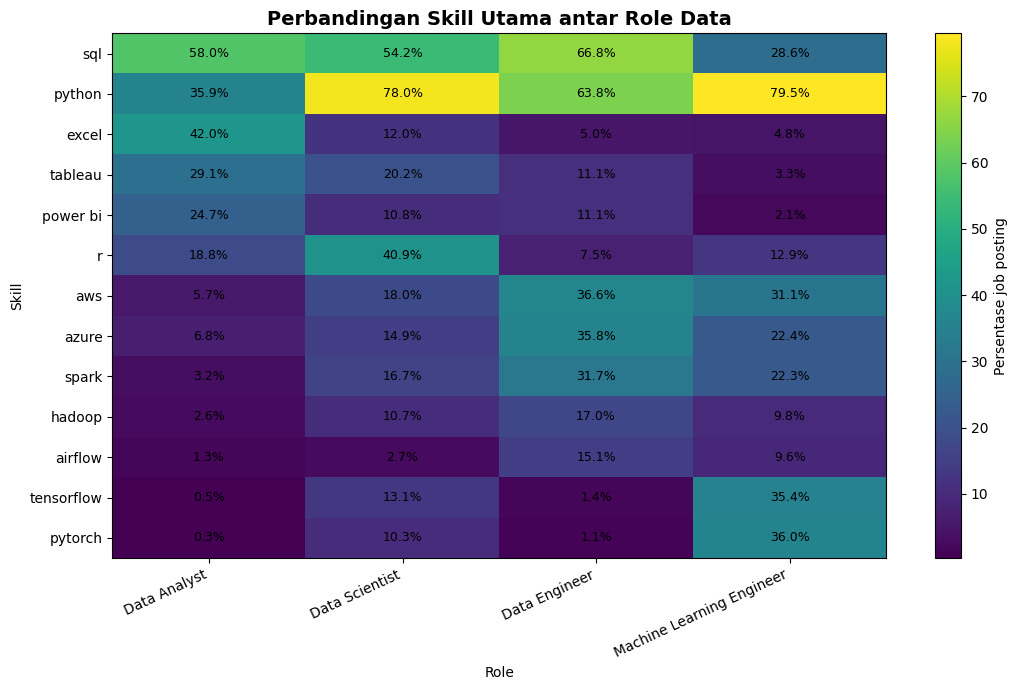

In [6]:
# Perbandingan skill antar role data

roles_to_compare = [
    "Data Analyst",
    "Data Scientist",
    "Data Engineer",
    "Machine Learning Engineer"
]

df_roles = df_with_skills[
    df_with_skills["job_title_short"].isin(roles_to_compare)
].copy()

df_role_skills = df_skills[
    df_skills["job_title_short"].isin(roles_to_compare)
].copy()

# Hitung total job posting per role
role_totals = (
    df_roles
    .groupby("job_title_short")
    .size()
    .reset_index(name="total_jobs")
)

# Hitung jumlah kemunculan tiap skill per role
skill_by_role = (
    df_role_skills
    .groupby(["job_title_short", "skill"])
    .size()
    .reset_index(name="total_mentions")
)

# Tambahkan total job per role
skill_by_role = skill_by_role.merge(role_totals, on="job_title_short", how="left")

# Hitung persentase skill terhadap total job posting role tersebut
skill_by_role["percentage"] = (
    skill_by_role["total_mentions"] / skill_by_role["total_jobs"] * 100
).round(2)

# Ambil top 10 skill untuk setiap role
top_skill_each_role = (
    skill_by_role
    .sort_values(["job_title_short", "percentage"], ascending=[True, False])
    .groupby("job_title_short")
    .head(10)
    .reset_index(drop=True)
)

print("=" * 80)
print("Top 10 skill paling dicari untuk setiap role")
print("=" * 80)

display(top_skill_each_role)


# Skill utama yang ingin dibandingkan antar role
main_skills = [
    "sql", "python", "excel", "tableau", "power bi", "r",
    "aws", "azure", "spark", "hadoop", "airflow", "tensorflow", "pytorch"
]

skill_matrix = (
    skill_by_role
    .pivot(index="skill", columns="job_title_short", values="percentage")
    .reindex(main_skills)
    .reindex(columns=roles_to_compare)
    .fillna(0)
)

print("\n" + "=" * 80)
print("Matriks persentase skill berdasarkan role")
print("=" * 80)

display(skill_matrix)


print("\n" + "=" * 80)
print("Visualisasi: Perbandingan skill utama antar role")
print("=" * 80)

plt.figure(figsize=(11, 7))

plt.imshow(skill_matrix, aspect="auto")

plt.title("Perbandingan Skill Utama antar Role Data", fontsize=14, fontweight="bold")
plt.xlabel("Role")
plt.ylabel("Skill")

plt.xticks(
    ticks=range(len(skill_matrix.columns)),
    labels=skill_matrix.columns,
    rotation=25,
    ha="right"
)

plt.yticks(
    ticks=range(len(skill_matrix.index)),
    labels=skill_matrix.index
)

# Tambahkan angka persentase di dalam heatmap
for i in range(skill_matrix.shape[0]):
    for j in range(skill_matrix.shape[1]):
        value = skill_matrix.iloc[i, j]
        plt.text(j, i, f"{value:.1f}%", ha="center", va="center", fontsize=9)

plt.colorbar(label="Persentase job posting")
plt.tight_layout()
plt.show()

Ringkasan jumlah job posting berdasarkan tipe kerja


,work_type,total_jobs,percentage
0,On-site / Not Mentioned,604854,90.45
1,Work From Home,63850,9.55



Top 15 skill paling banyak dicari untuk Work From Home
Total job posting Work From Home yang punya data skill: 63,850


,skill,total_mentions,percentage
158,python,40492,63.42
194,sql,40249,63.04
15,aws,18274,28.62
16,azure,13907,21.78
189,spark,13049,20.44
207,tableau,11891,18.62
162,r,10686,16.74
60,excel,9341,14.63
91,java,8050,12.61
187,snowflake,7939,12.43



Visualisasi 1: Top skill untuk Work From Home


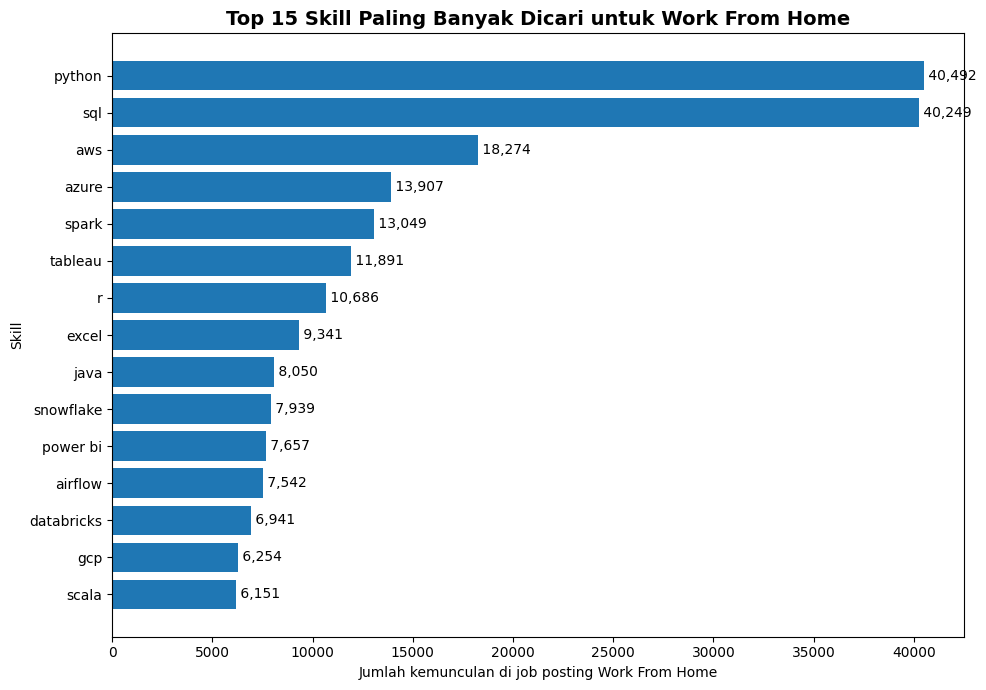


Perbandingan skill utama: Work From Home vs On-site / Not Mentioned


,skill,remote_percentage,non_remote_percentage,gap_remote_vs_non_remote
15,aws,28.62,21.01,7.61
167,python,63.42,56.28,7.14
204,sql,63.04,56.97,6.06
197,snowflake,12.43,7.78,4.65
199,spark,20.44,16.79,3.65
42,databricks,10.87,7.64,3.23
16,azure,21.78,19.61,2.17
53,docker,7.90,6.06,1.84
108,kubernetes,7.20,5.41,1.79
168,pytorch,5.23,3.96,1.28



Visualisasi 2: Perbandingan persentase skill remote dan non-remote


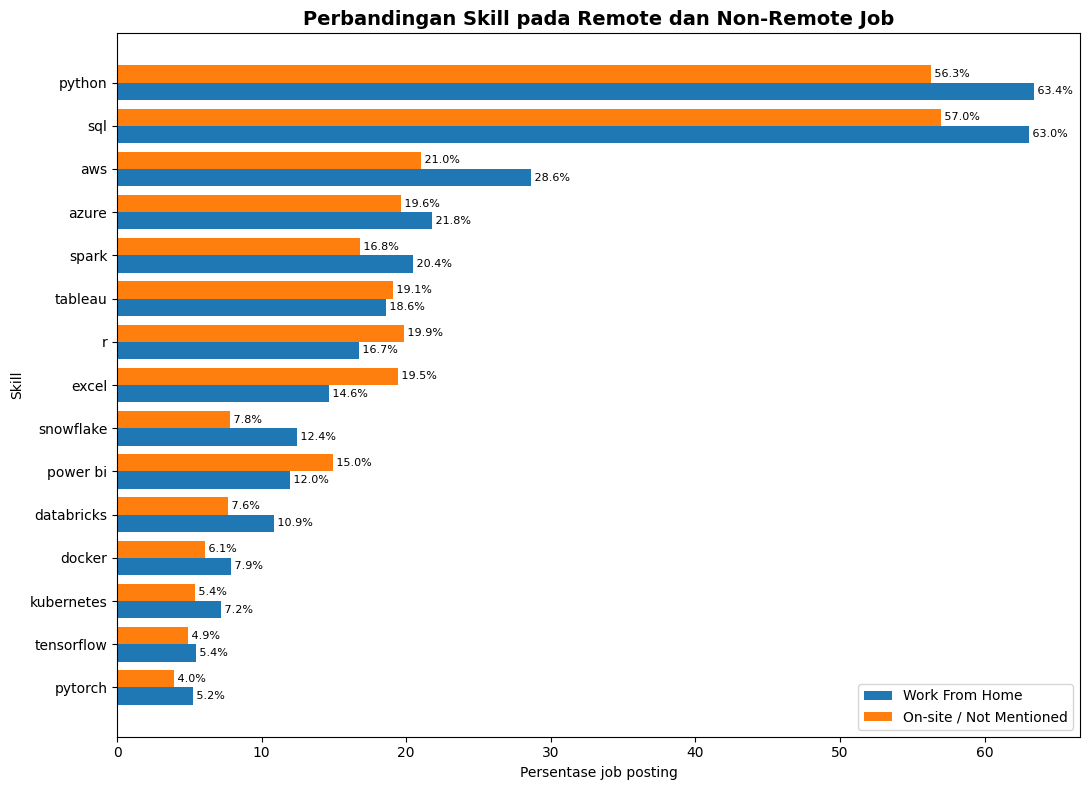

In [7]:
# Skill yang paling dicari untuk remote job

remote_jobs = df_with_skills[df_with_skills["job_work_from_home"] == True].copy()
non_remote_jobs = df_with_skills[df_with_skills["job_work_from_home"] == False].copy()

remote_skills = df_skills[df_skills["job_work_from_home"] == True].copy()
non_remote_skills = df_skills[df_skills["job_work_from_home"] == False].copy()

print("=" * 80)
print("Ringkasan jumlah job posting berdasarkan tipe kerja")
print("=" * 80)

work_type_summary = (
    df_with_skills
    .groupby("work_type")
    .size()
    .reset_index(name="total_jobs")
    .sort_values("total_jobs", ascending=False)
)

work_type_summary["percentage"] = (
    work_type_summary["total_jobs"] / df_with_skills.shape[0] * 100
).round(2)

display(work_type_summary)


# Hitung top skill untuk work from home
top_remote_skills = (
    remote_skills
    .groupby("skill")
    .size()
    .reset_index(name="total_mentions")
    .sort_values("total_mentions", ascending=False)
    .head(15)
)

top_remote_skills["percentage"] = (
    top_remote_skills["total_mentions"] / remote_jobs.shape[0] * 100
).round(2)

print("\n" + "=" * 80)
print("Top 15 skill paling banyak dicari untuk Work From Home")
print("=" * 80)

print(f"Total job posting Work From Home yang punya data skill: {remote_jobs.shape[0]:,}")
display(top_remote_skills)


print("\n" + "=" * 80)
print("Visualisasi 1: Top skill untuk Work From Home")
print("=" * 80)

plt.figure(figsize=(10, 7))

plt.barh(
    top_remote_skills["skill"][::-1],
    top_remote_skills["total_mentions"][::-1]
)

plt.title("Top 15 Skill Paling Banyak Dicari untuk Work From Home", fontsize=14, fontweight="bold")
plt.xlabel("Jumlah kemunculan di job posting Work From Home")
plt.ylabel("Skill")

for index, value in enumerate(top_remote_skills["total_mentions"][::-1]):
    plt.text(value, index, f" {value:,}", va="center")

plt.tight_layout()
plt.show()


# Bandingkan skill utama antara remote dan non-remote
remote_skill_pct = (
    remote_skills
    .groupby("skill")
    .size()
    .reset_index(name="remote_mentions")
)

remote_skill_pct["remote_percentage"] = (
    remote_skill_pct["remote_mentions"] / remote_jobs.shape[0] * 100
)

non_remote_skill_pct = (
    non_remote_skills
    .groupby("skill")
    .size()
    .reset_index(name="non_remote_mentions")
)

non_remote_skill_pct["non_remote_percentage"] = (
    non_remote_skill_pct["non_remote_mentions"] / non_remote_jobs.shape[0] * 100
)

remote_compare = remote_skill_pct.merge(
    non_remote_skill_pct,
    on="skill",
    how="outer"
).fillna(0)

remote_compare["gap_remote_vs_non_remote"] = (
    remote_compare["remote_percentage"] - remote_compare["non_remote_percentage"]
)

main_remote_skills = [
    "sql", "python", "excel", "tableau", "power bi", "r",
    "aws", "azure", "spark", "snowflake", "databricks",
    "docker", "kubernetes", "tensorflow", "pytorch"
]

remote_compare_main = (
    remote_compare[remote_compare["skill"].isin(main_remote_skills)]
    .copy()
    .sort_values("gap_remote_vs_non_remote", ascending=False)
)

remote_compare_main["remote_percentage"] = remote_compare_main["remote_percentage"].round(2)
remote_compare_main["non_remote_percentage"] = remote_compare_main["non_remote_percentage"].round(2)
remote_compare_main["gap_remote_vs_non_remote"] = remote_compare_main["gap_remote_vs_non_remote"].round(2)

print("\n" + "=" * 80)
print("Perbandingan skill utama: Work From Home vs On-site / Not Mentioned")
print("=" * 80)

display(
    remote_compare_main[
        ["skill", "remote_percentage", "non_remote_percentage", "gap_remote_vs_non_remote"]
    ]
)


print("\n" + "=" * 80)
print("Visualisasi 2: Perbandingan persentase skill remote dan non-remote")
print("=" * 80)

comparison_plot = remote_compare_main.sort_values("remote_percentage", ascending=True)

y_pos = np.arange(len(comparison_plot))
bar_height = 0.4

plt.figure(figsize=(11, 8))

plt.barh(
    y_pos - bar_height / 2,
    comparison_plot["remote_percentage"],
    height=bar_height,
    label="Work From Home"
)

plt.barh(
    y_pos + bar_height / 2,
    comparison_plot["non_remote_percentage"],
    height=bar_height,
    label="On-site / Not Mentioned"
)

plt.title("Perbandingan Skill pada Remote dan Non-Remote Job", fontsize=14, fontweight="bold")
plt.xlabel("Persentase job posting")
plt.ylabel("Skill")
plt.yticks(y_pos, comparison_plot["skill"])
plt.legend()

for i, value in enumerate(comparison_plot["remote_percentage"]):
    plt.text(value, i - bar_height / 2, f" {value:.1f}%", va="center", fontsize=8)

for i, value in enumerate(comparison_plot["non_remote_percentage"]):
    plt.text(value, i + bar_height / 2, f" {value:.1f}%", va="center", fontsize=8)

plt.tight_layout()
plt.show()

Ringkasan data salary yang tersedia
Total baris skill dengan data salary: 116,682
Jumlah job posting unik dengan salary: 20,170
Jumlah skill unik dengan salary: 219

Top 15 skill dengan median salary tertinggi, minimal 100 kemunculan


,skill,total_mentions,median_salary,average_salary
109,mongo,256,173500.0,169527.0
23,cassandra,524,150000.0,153617.0
74,golang,110,147500.0,142354.0
114,neo4j,124,147500.0,148160.0
91,kafka,1634,147500.0,144475.0
12,atlassian,101,147500.0,138651.0
144,pytorch,1079,147500.0,144620.0
161,scala,1905,147500.0,144998.0
151,redis,117,147500.0,139672.0
0,airflow,1497,147090.0,142256.0



Visualisasi 1: Skill dengan median salary tertinggi


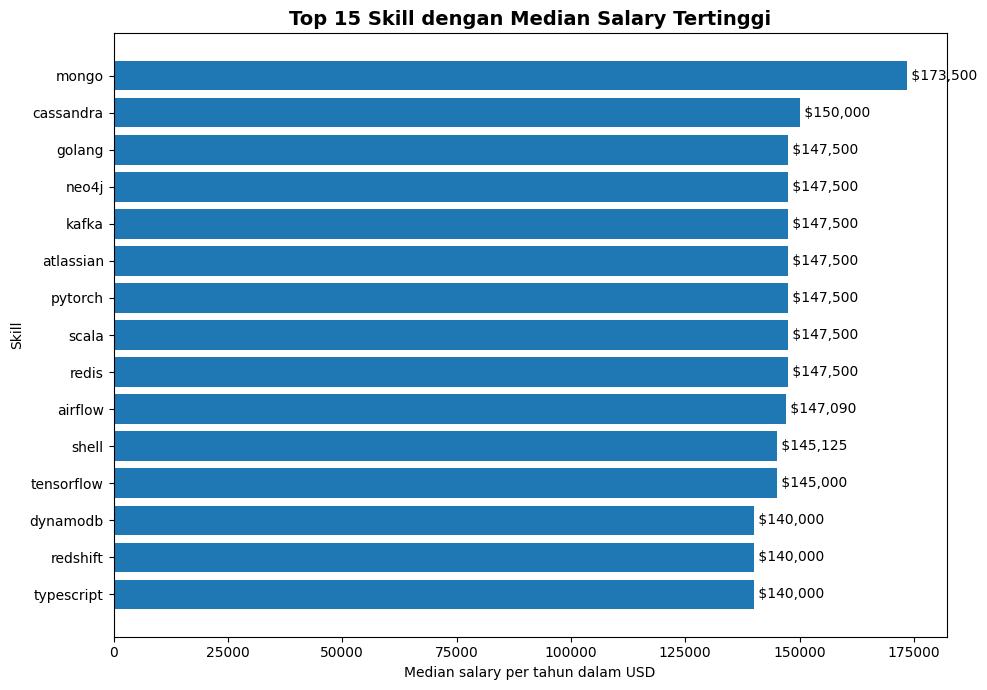


Top 15 skill Data Analyst dengan median salary tertinggi, minimal 30 kemunculan


,skill,total_mentions,median_salary,average_salary
130,shell,44,119575.0,111496.0
70,kafka,38,115095.0,130389.0
73,linux,58,112150.0,114883.0
50,gcp,78,111175.0,112553.0
124,scala,59,111175.0,115480.0
135,spark,187,111175.0,112774.0
59,hadoop,140,111175.0,110488.0
110,pyspark,48,111175.0,114872.0
0,airflow,72,111175.0,116819.0
26,confluence,63,111175.0,114682.0



Visualisasi 2: Skill Data Analyst dengan median salary tertinggi


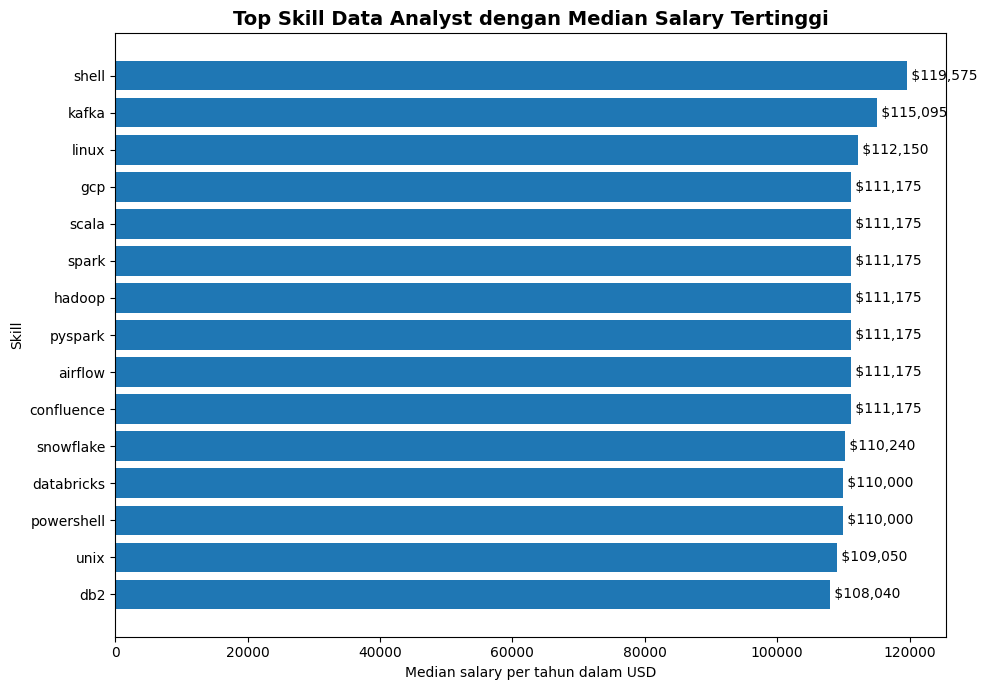

In [8]:
# Skill yang berhubungan dengan salary tinggi

salary_skill_data = df_skills[
    df_skills["salary_year_avg"].notna()
].copy()

print("=" * 80)
print("Ringkasan data salary yang tersedia")
print("=" * 80)

print(f"Total baris skill dengan data salary: {salary_skill_data.shape[0]:,}")
print(f"Jumlah job posting unik dengan salary: {salary_skill_data.index.nunique():,}")
print(f"Jumlah skill unik dengan salary: {salary_skill_data['skill'].nunique():,}")


# Hitung median salary untuk setiap skill
skill_salary = (
    salary_skill_data
    .groupby("skill")
    .agg(
        total_mentions=("skill", "count"),
        median_salary=("salary_year_avg", "median"),
        average_salary=("salary_year_avg", "mean")
    )
    .reset_index()
)

# Filter supaya skill dengan data terlalu sedikit tidak masuk ranking
min_mentions = 100

skill_salary_filtered = (
    skill_salary[skill_salary["total_mentions"] >= min_mentions]
    .sort_values("median_salary", ascending=False)
    .head(15)
    .copy()
)

skill_salary_filtered["median_salary"] = skill_salary_filtered["median_salary"].round(0)
skill_salary_filtered["average_salary"] = skill_salary_filtered["average_salary"].round(0)

print("\n" + "=" * 80)
print(f"Top 15 skill dengan median salary tertinggi, minimal {min_mentions} kemunculan")
print("=" * 80)

display(skill_salary_filtered)


print("\n" + "=" * 80)
print("Visualisasi 1: Skill dengan median salary tertinggi")
print("=" * 80)

plt.figure(figsize=(10, 7))

plt.barh(
    skill_salary_filtered["skill"][::-1],
    skill_salary_filtered["median_salary"][::-1]
)

plt.title("Top 15 Skill dengan Median Salary Tertinggi", fontsize=14, fontweight="bold")
plt.xlabel("Median salary per tahun dalam USD")
plt.ylabel("Skill")

for index, value in enumerate(skill_salary_filtered["median_salary"][::-1]):
    plt.text(value, index, f" ${value:,.0f}", va="center")

plt.tight_layout()
plt.show()


# Khusus Data Analyst
da_salary_skill_data = salary_skill_data[
    salary_skill_data["job_title_short"] == "Data Analyst"
].copy()

da_skill_salary = (
    da_salary_skill_data
    .groupby("skill")
    .agg(
        total_mentions=("skill", "count"),
        median_salary=("salary_year_avg", "median"),
        average_salary=("salary_year_avg", "mean")
    )
    .reset_index()
)

min_mentions_da = 30

da_skill_salary_filtered = (
    da_skill_salary[da_skill_salary["total_mentions"] >= min_mentions_da]
    .sort_values("median_salary", ascending=False)
    .head(15)
    .copy()
)

da_skill_salary_filtered["median_salary"] = da_skill_salary_filtered["median_salary"].round(0)
da_skill_salary_filtered["average_salary"] = da_skill_salary_filtered["average_salary"].round(0)

print("\n" + "=" * 80)
print(f"Top 15 skill Data Analyst dengan median salary tertinggi, minimal {min_mentions_da} kemunculan")
print("=" * 80)

display(da_skill_salary_filtered)


print("\n" + "=" * 80)
print("Visualisasi 2: Skill Data Analyst dengan median salary tertinggi")
print("=" * 80)

plt.figure(figsize=(10, 7))

plt.barh(
    da_skill_salary_filtered["skill"][::-1],
    da_skill_salary_filtered["median_salary"][::-1]
)

plt.title("Top Skill Data Analyst dengan Median Salary Tertinggi", fontsize=14, fontweight="bold")
plt.xlabel("Median salary per tahun dalam USD")
plt.ylabel("Skill")

for index, value in enumerate(da_skill_salary_filtered["median_salary"][::-1]):
    plt.text(value, index, f" ${value:,.0f}", va="center")

plt.tight_layout()
plt.show()

Skill Priority Matrix untuk Data Analyst


,skill,total_mentions,demand_percentage,salary_mentions,median_salary,category
140,sql,92428,57.99,3079,92500.0,Core skill
44,excel,66860,41.95,2135,84479.0,Core skill
111,python,57190,35.88,1838,98500.0,High demand & high salary
149,tableau,46455,29.14,1657,95000.0,Core skill
106,power bi,39380,24.71,1042,90000.0,Core skill
114,r,29996,18.82,1073,92528.0,Core skill
122,sas,13999,8.78,503,90000.0,Core skill
107,powerpoint,13822,8.67,518,85000.0,Core skill
172,word,13562,8.51,523,80000.0,Core skill
121,sap,11280,7.08,182,90000.0,Core skill



Ringkasan kategori skill


,category,total_skills,avg_demand_percentage,median_salary
0,Core skill,23,11.02,90000.0
1,High demand & high salary,14,5.68,105000.0
2,Premium niche skill,23,1.06,103736.0
3,Supporting skill,14,1.06,86450.0



Visualisasi: Skill Priority Matrix Data Analyst


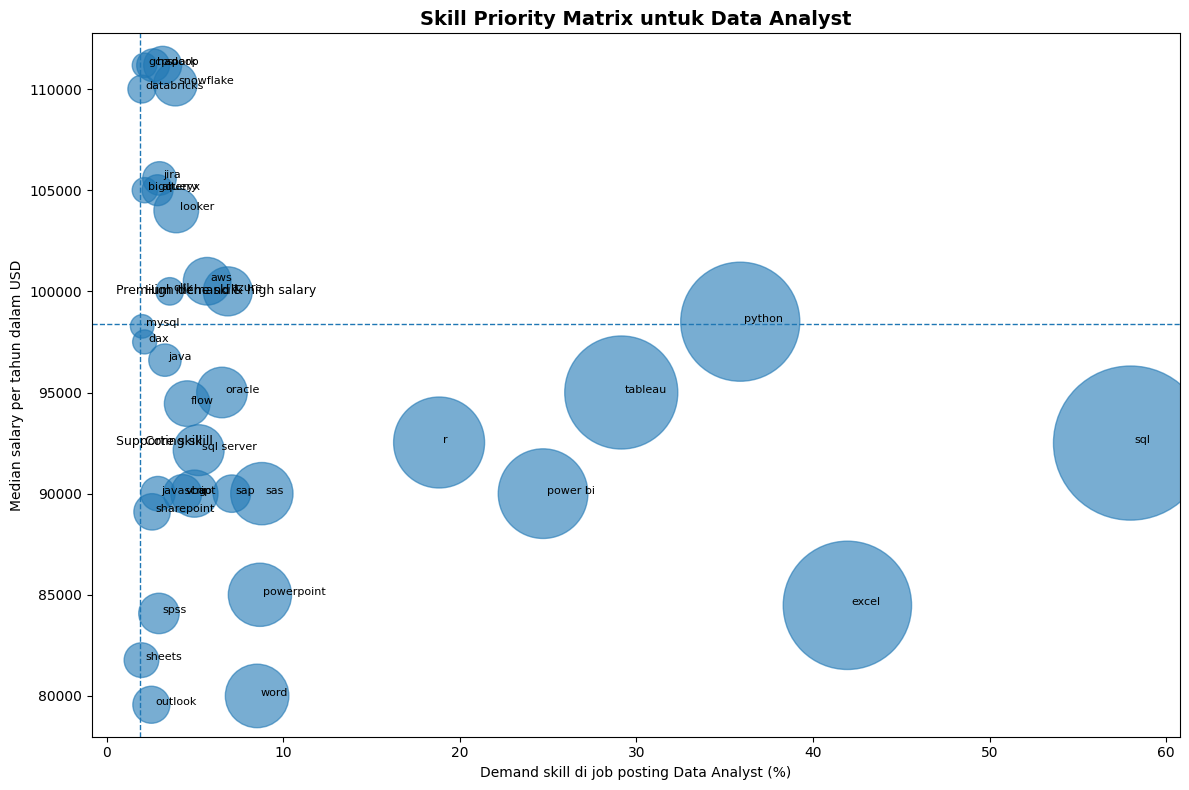

In [9]:
# Skill Priority Matrix untuk Data Analyst

# Data demand skill Data Analyst
da_skill_demand = (
    data_analyst_skills
    .groupby("skill")
    .size()
    .reset_index(name="total_mentions")
)

da_skill_demand["demand_percentage"] = (
    da_skill_demand["total_mentions"] / total_data_analyst_jobs * 100
)

# Data salary skill Data Analyst
da_skill_salary_all = (
    da_salary_skill_data
    .groupby("skill")
    .agg(
        salary_mentions=("skill", "count"),
        median_salary=("salary_year_avg", "median")
    )
    .reset_index()
)

# Gabungkan demand dan salary
da_skill_priority = da_skill_demand.merge(
    da_skill_salary_all,
    on="skill",
    how="inner"
)

# Filter supaya skill dengan data salary terlalu sedikit tidak terlalu bias
min_salary_mentions = 30

da_skill_priority = da_skill_priority[
    da_skill_priority["salary_mentions"] >= min_salary_mentions
].copy()

# Rapihin angka
da_skill_priority["demand_percentage"] = da_skill_priority["demand_percentage"].round(2)
da_skill_priority["median_salary"] = da_skill_priority["median_salary"].round(0)

# Batas sederhana untuk kategori
demand_threshold = da_skill_priority["demand_percentage"].median()
salary_threshold = da_skill_priority["median_salary"].median()

def skill_category(row):
    if row["demand_percentage"] >= demand_threshold and row["median_salary"] >= salary_threshold:
        return "High demand & high salary"
    elif row["demand_percentage"] >= demand_threshold and row["median_salary"] < salary_threshold:
        return "Core skill"
    elif row["demand_percentage"] < demand_threshold and row["median_salary"] >= salary_threshold:
        return "Premium niche skill"
    else:
        return "Supporting skill"

da_skill_priority["category"] = da_skill_priority.apply(skill_category, axis=1)

# Ambil skill yang menarik untuk divisualisasikan
important_skills = (
    da_skill_priority
    .sort_values(["demand_percentage", "median_salary"], ascending=False)
    .head(35)
    .copy()
)

print("=" * 80)
print("Skill Priority Matrix untuk Data Analyst")
print("=" * 80)

display(
    important_skills[
        ["skill", "total_mentions", "demand_percentage", "salary_mentions", "median_salary", "category"]
    ].sort_values("demand_percentage", ascending=False)
)


print("\n" + "=" * 80)
print("Ringkasan kategori skill")
print("=" * 80)

category_summary = (
    da_skill_priority
    .groupby("category")
    .agg(
        total_skills=("skill", "count"),
        avg_demand_percentage=("demand_percentage", "mean"),
        median_salary=("median_salary", "median")
    )
    .reset_index()
)

category_summary["avg_demand_percentage"] = category_summary["avg_demand_percentage"].round(2)
category_summary["median_salary"] = category_summary["median_salary"].round(0)

display(category_summary)


print("\n" + "=" * 80)
print("Visualisasi: Skill Priority Matrix Data Analyst")
print("=" * 80)

plt.figure(figsize=(12, 8))

plt.scatter(
    important_skills["demand_percentage"],
    important_skills["median_salary"],
    s=important_skills["salary_mentions"] * 4,
    alpha=0.6
)

plt.axvline(demand_threshold, linestyle="--", linewidth=1)
plt.axhline(salary_threshold, linestyle="--", linewidth=1)

plt.title("Skill Priority Matrix untuk Data Analyst", fontsize=14, fontweight="bold")
plt.xlabel("Demand skill di job posting Data Analyst (%)")
plt.ylabel("Median salary per tahun dalam USD")

for _, row in important_skills.iterrows():
    plt.text(
        row["demand_percentage"] + 0.2,
        row["median_salary"],
        row["skill"],
        fontsize=8
    )

plt.text(
    demand_threshold + 0.3,
    salary_threshold + 1500,
    "High demand & high salary",
    fontsize=9
)

plt.text(
    demand_threshold + 0.3,
    salary_threshold - 6000,
    "Core skill",
    fontsize=9
)

plt.text(
    0.5,
    salary_threshold + 1500,
    "Premium niche skill",
    fontsize=9
)

plt.text(
    0.5,
    salary_threshold - 6000,
    "Supporting skill",
    fontsize=9
)

plt.tight_layout()
plt.show()

Rekomendasi skill Data Analyst berdasarkan prioritas belajar


,skill,learning_priority,demand_percentage,median_salary,total_mentions,salary_mentions
140,sql,Wajib dipelajari,57.99,92500.0,92428,3079
44,excel,Wajib dipelajari,41.95,84479.0,66860,2135
111,python,Wajib dipelajari,35.88,98500.0,57190,1838
149,tableau,BI & reporting tools,29.14,95000.0,46455,1657
106,power bi,BI & reporting tools,24.71,90000.0,39380,1042
74,looker,BI & reporting tools,3.93,104000.0,6259,259
113,qlik,BI & reporting tools,3.56,100000.0,5681,98
12,azure,Skill premium,6.85,100000.0,10913,312
11,aws,Skill premium,5.68,100500.0,9047,294
133,snowflake,Skill premium,3.88,110240.0,6178,245



Ringkasan prioritas skill


,learning_priority,total_skills,avg_demand_percentage,median_salary
0,Wajib dipelajari,3,45.27,92500.0
1,BI & reporting tools,4,15.34,97500.0
2,Skill premium,10,3.05,110708.0
3,Skill pendukung utama,7,9.08,90000.0
4,Skill tambahan,50,1.62,98134.0



Visualisasi: Top skill rekomendasi untuk Data Analyst


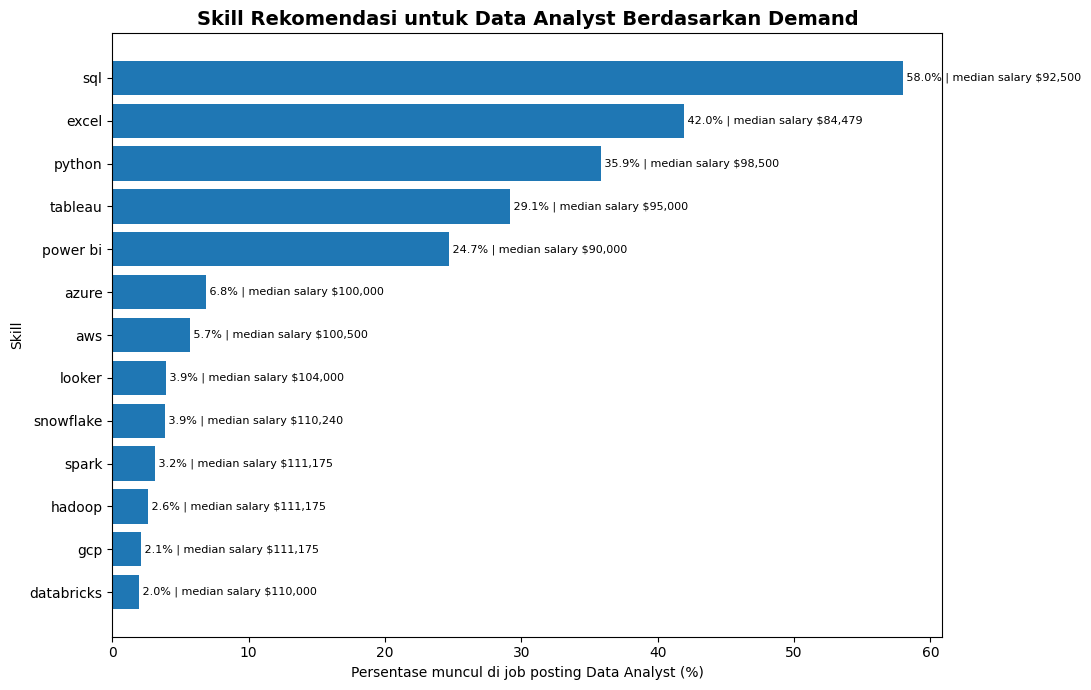

In [10]:
# Rekomendasi skill Data Analyst berdasarkan demand dan salary

skill_recommendation = da_skill_priority.copy()

def learning_priority(row):
    skill = row["skill"]

    wajib = ["sql", "excel", "python"]
    bi_tools = ["tableau", "power bi", "looker", "qlik"]
    premium = [
        "snowflake", "spark", "hadoop", "gcp", "aws", "azure",
        "databricks", "airflow", "kafka", "bigquery"
    ]

    if skill in wajib:
        return "Wajib dipelajari"
    elif skill in bi_tools:
        return "BI & reporting tools"
    elif skill in premium:
        return "Skill premium"
    elif row["demand_percentage"] >= 5:
        return "Skill pendukung utama"
    else:
        return "Skill tambahan"

skill_recommendation["learning_priority"] = skill_recommendation.apply(learning_priority, axis=1)

priority_order = [
    "Wajib dipelajari",
    "BI & reporting tools",
    "Skill premium",
    "Skill pendukung utama",
    "Skill tambahan"
]

skill_recommendation["learning_priority"] = pd.Categorical(
    skill_recommendation["learning_priority"],
    categories=priority_order,
    ordered=True
)

final_skill_recommendation = (
    skill_recommendation
    .sort_values(
        ["learning_priority", "demand_percentage", "median_salary"],
        ascending=[True, False, False]
    )
)

print("=" * 85)
print("Rekomendasi skill Data Analyst berdasarkan prioritas belajar")
print("=" * 85)

display(
    final_skill_recommendation[
        [
            "skill",
            "learning_priority",
            "demand_percentage",
            "median_salary",
            "total_mentions",
            "salary_mentions"
        ]
    ].head(35)
)


print("\n" + "=" * 85)
print("Ringkasan prioritas skill")
print("=" * 85)

priority_summary = (
    final_skill_recommendation
    .groupby("learning_priority", observed=True)
    .agg(
        total_skills=("skill", "count"),
        avg_demand_percentage=("demand_percentage", "mean"),
        median_salary=("median_salary", "median")
    )
    .reset_index()
)

priority_summary["avg_demand_percentage"] = priority_summary["avg_demand_percentage"].round(2)
priority_summary["median_salary"] = priority_summary["median_salary"].round(0)

display(priority_summary)


print("\n" + "=" * 85)
print("Visualisasi: Top skill rekomendasi untuk Data Analyst")
print("=" * 85)

skills_for_plot = final_skill_recommendation[
    final_skill_recommendation["skill"].isin([
        "sql", "excel", "python", "tableau", "power bi", "looker",
        "snowflake", "spark", "hadoop", "gcp", "aws", "azure", "databricks"
    ])
].copy()

skills_for_plot = skills_for_plot.sort_values("demand_percentage", ascending=True)

plt.figure(figsize=(11, 7))

plt.barh(
    skills_for_plot["skill"],
    skills_for_plot["demand_percentage"]
)

plt.title("Skill Rekomendasi untuk Data Analyst Berdasarkan Demand", fontsize=14, fontweight="bold")
plt.xlabel("Persentase muncul di job posting Data Analyst (%)")
plt.ylabel("Skill")

for index, value in enumerate(skills_for_plot["demand_percentage"]):
    salary = skills_for_plot.iloc[index]["median_salary"]
    plt.text(
        value,
        index,
        f" {value:.1f}% | median salary ${salary:,.0f}",
        va="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [11]:
# Buka dataset salary dan rapihin data awal

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

df_salary = pd.read_csv("/content/ds_salaries.csv")

# Hapus kolom index tambahan kalau ada
if "Unnamed: 0" in df_salary.columns:
    df_salary = df_salary.drop(columns=["Unnamed: 0"])

# Rapihin label experience level
experience_map = {
    "EN": "Entry Level",
    "MI": "Mid Level",
    "SE": "Senior Level",
    "EX": "Executive Level"
}

# Rapihin label employment type
employment_map = {
    "FT": "Full-time",
    "PT": "Part-time",
    "CT": "Contract",
    "FL": "Freelance"
}

# Rapihin label remote ratio
remote_map = {
    0: "On-site",
    50: "Hybrid",
    100: "Fully Remote"
}

# Rapihin label company size
company_size_map = {
    "S": "Small",
    "M": "Medium",
    "L": "Large"
}

df_salary["experience_label"] = df_salary["experience_level"].map(experience_map)
df_salary["employment_label"] = df_salary["employment_type"].map(employment_map)
df_salary["remote_label"] = df_salary["remote_ratio"].map(remote_map)
df_salary["company_size_label"] = df_salary["company_size"].map(company_size_map)

print("=" * 70)
print("Dataset salary berhasil dibuka")
print("=" * 70)

print(f"Jumlah baris : {df_salary.shape[0]:,}")
print(f"Jumlah kolom : {df_salary.shape[1]}")

print("\nDaftar kolom:")
print(df_salary.columns.tolist())

print("\nContoh data:")
display(df_salary.head())

print("\nMissing value:")
display(
    pd.DataFrame({
        "missing_count": df_salary.isna().sum(),
        "missing_percentage": (df_salary.isna().mean() * 100).round(2)
    }).sort_values("missing_percentage", ascending=False)
)

print("\nRingkasan salary dalam USD:")
display(df_salary["salary_in_usd"].describe().round(2))

Dataset salary berhasil dibuka
Jumlah baris : 607
Jumlah kolom : 15

Daftar kolom:
['work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size', 'experience_label', 'employment_label', 'remote_label', 'company_size_label']

Contoh data:


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,experience_label,employment_label,remote_label,company_size_label
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L,Mid Level,Full-time,On-site,Large
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S,Senior Level,Full-time,On-site,Small
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M,Senior Level,Full-time,Hybrid,Medium
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S,Mid Level,Full-time,On-site,Small
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L,Senior Level,Full-time,Hybrid,Large



Missing value:


,missing_count,missing_percentage
work_year,0,0.0
experience_level,0,0.0
employment_type,0,0.0
job_title,0,0.0
salary,0,0.0
salary_currency,0,0.0
salary_in_usd,0,0.0
employee_residence,0,0.0
remote_ratio,0,0.0
company_location,0,0.0



Ringkasan salary dalam USD:


,salary_in_usd
count,607.00
mean,112297.87
std,70957.26
min,2859.00
25%,62726.00
50%,101570.00
75%,150000.00
max,600000.00


Top job title paling banyak muncul


,job_title,total
0,Data Scientist,143
1,Data Engineer,132
2,Data Analyst,97
3,Machine Learning Engineer,41
4,Research Scientist,16
5,Data Science Manager,12
6,Data Architect,11
7,Machine Learning Scientist,8
8,Big Data Engineer,8
9,Director of Data Science,7



Visualisasi 1: Top job title paling banyak muncul


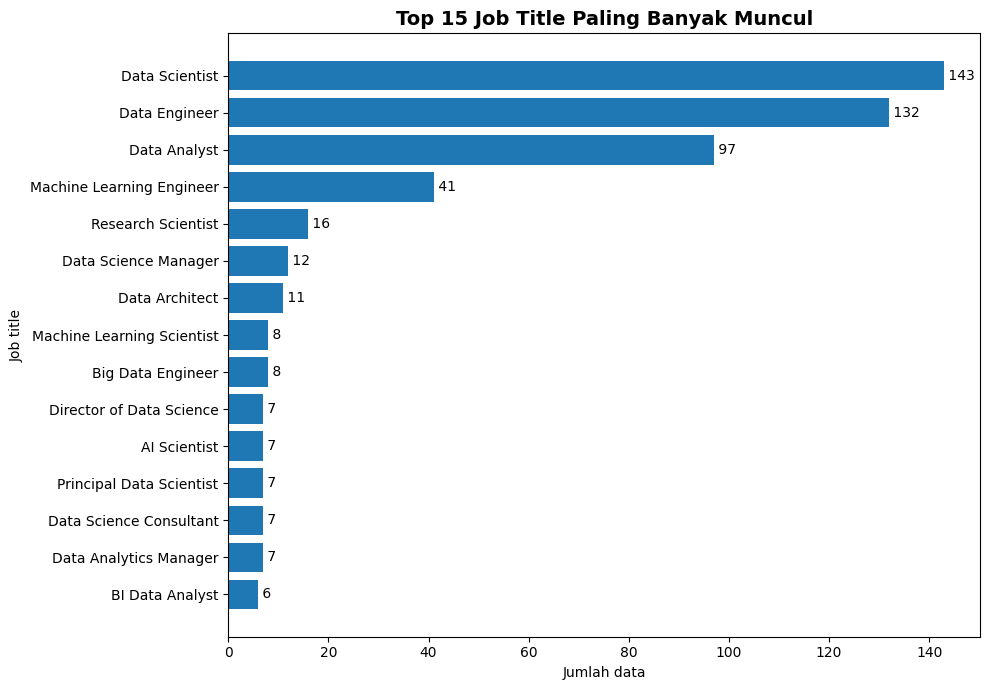


Ringkasan role group


,role_group,total,percentage
0,Data Scientist,175,28.83
1,Data Engineer,160,26.36
2,Data Analyst,119,19.60
3,Machine Learning / AI,75,12.36
4,Data Science Management,33,5.44
5,Other Data Role,17,2.80
6,Analytics / BI,17,2.80
7,Data Architect,11,1.81



Visualisasi 2: Role group paling banyak muncul


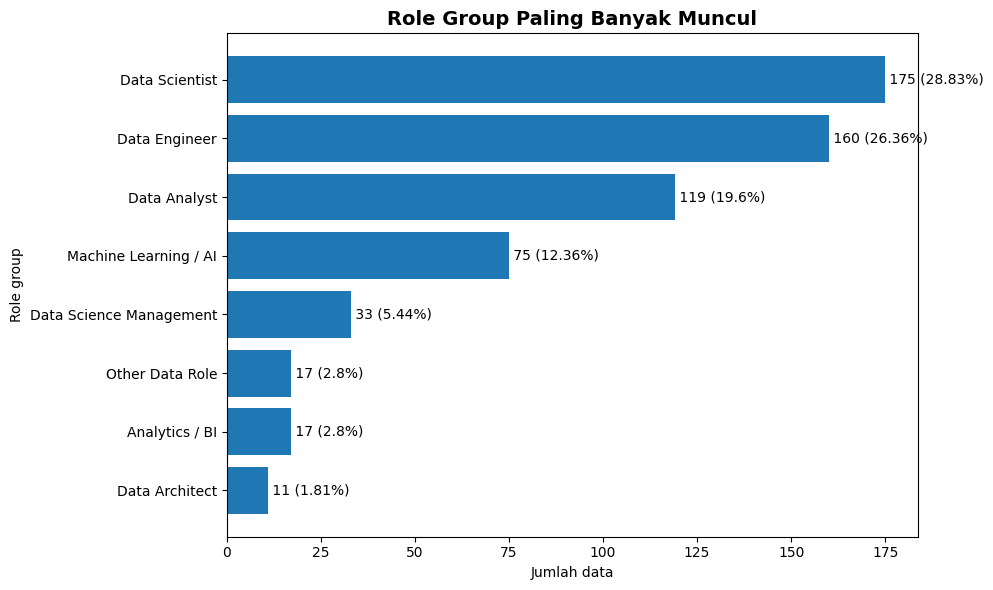

In [12]:
# Analisis role paling banyak muncul

print("=" * 75)
print("Top job title paling banyak muncul")
print("=" * 75)

top_job_titles = (
    df_salary["job_title"]
    .value_counts()
    .head(15)
    .reset_index()
)

top_job_titles.columns = ["job_title", "total"]

display(top_job_titles)


print("\n" + "=" * 75)
print("Visualisasi 1: Top job title paling banyak muncul")
print("=" * 75)

plt.figure(figsize=(10, 7))

plt.barh(
    top_job_titles["job_title"][::-1],
    top_job_titles["total"][::-1]
)

plt.title("Top 15 Job Title Paling Banyak Muncul", fontsize=14, fontweight="bold")
plt.xlabel("Jumlah data")
plt.ylabel("Job title")

for index, value in enumerate(top_job_titles["total"][::-1]):
    plt.text(value, index, f" {value}", va="center")

plt.tight_layout()
plt.show()


# Bikin role group supaya analisis lebih enak dibaca
def group_role(title):
    title = title.lower()

    if "data analyst" in title or "product data analyst" in title:
        return "Data Analyst"
    elif "data scientist" in title or "research scientist" in title:
        return "Data Scientist"
    elif "data engineer" in title or "big data engineer" in title or "etl" in title:
        return "Data Engineer"
    elif "machine learning" in title or "ml engineer" in title or "ai scientist" in title:
        return "Machine Learning / AI"
    elif "analytics" in title or "bi" in title or "business analyst" in title:
        return "Analytics / BI"
    elif "data architect" in title:
        return "Data Architect"
    elif "data science" in title:
        return "Data Science Management"
    else:
        return "Other Data Role"

df_salary["role_group"] = df_salary["job_title"].apply(group_role)

role_group_summary = (
    df_salary["role_group"]
    .value_counts()
    .reset_index()
)

role_group_summary.columns = ["role_group", "total"]
role_group_summary["percentage"] = (
    role_group_summary["total"] / len(df_salary) * 100
).round(2)

print("\n" + "=" * 75)
print("Ringkasan role group")
print("=" * 75)

display(role_group_summary)


print("\n" + "=" * 75)
print("Visualisasi 2: Role group paling banyak muncul")
print("=" * 75)

plt.figure(figsize=(10, 6))

plt.barh(
    role_group_summary["role_group"][::-1],
    role_group_summary["total"][::-1]
)

plt.title("Role Group Paling Banyak Muncul", fontsize=14, fontweight="bold")
plt.xlabel("Jumlah data")
plt.ylabel("Role group")

for index, value in enumerate(role_group_summary["total"][::-1]):
    percentage = role_group_summary["percentage"][::-1].iloc[index]
    plt.text(value, index, f" {value} ({percentage}%)", va="center")

plt.tight_layout()
plt.show()

Ringkasan salary berdasarkan role group


,role_group,total_data,median_salary,average_salary,min_salary,max_salary
2,Data Architect,11,180000.0,177874.0,90700,266400
4,Data Science Management,33,141846.0,138354.0,5707,325000
0,Analytics / BI,17,120000.0,138461.0,20000,405000
3,Data Engineer,160,107400.0,115048.0,4000,600000
5,Data Scientist,175,104890.0,114576.0,2859,450000
1,Data Analyst,119,90320.0,93200.0,6072,450000
6,Machine Learning / AI,75,87425.0,108650.0,12000,423000
7,Other Data Role,17,70000.0,93572.0,5409,235000



Visualisasi 1: Median salary berdasarkan role group


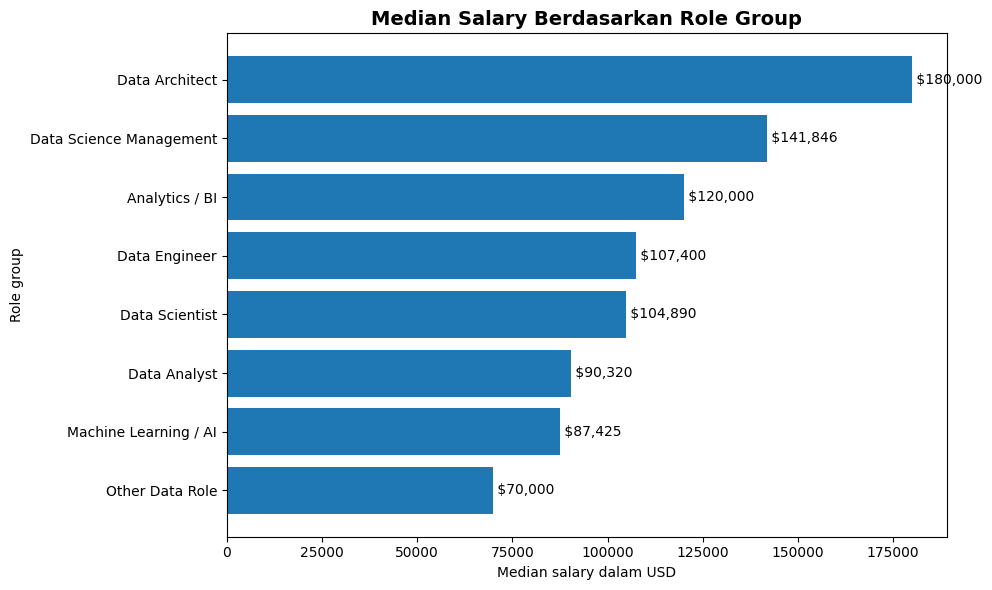


Visualisasi 2: Distribusi salary berdasarkan role group


/tmp/ipykernel_1843/160663476.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


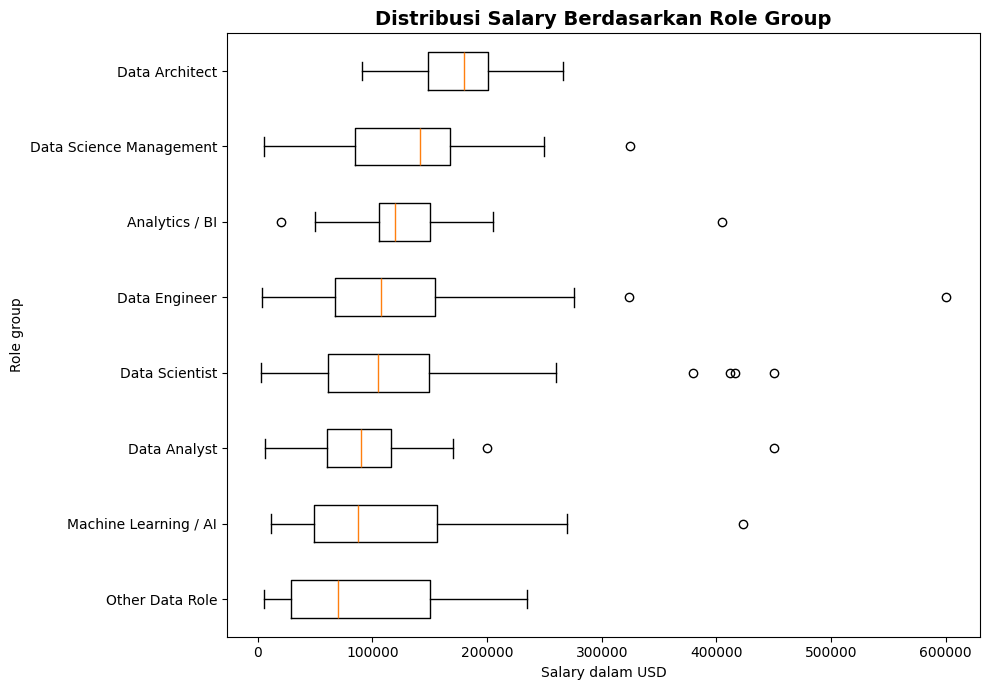


Fokus perbandingan role utama


,role_group,total_data,median_salary,average_salary,min_salary,max_salary
3,Data Engineer,160,107400.0,115048.0,4000,600000
5,Data Scientist,175,104890.0,114576.0,2859,450000
1,Data Analyst,119,90320.0,93200.0,6072,450000
6,Machine Learning / AI,75,87425.0,108650.0,12000,423000


In [13]:
# Perbandingan salary Data Analyst vs role lain

salary_by_role = (
    df_salary
    .groupby("role_group")
    .agg(
        total_data=("salary_in_usd", "count"),
        median_salary=("salary_in_usd", "median"),
        average_salary=("salary_in_usd", "mean"),
        min_salary=("salary_in_usd", "min"),
        max_salary=("salary_in_usd", "max")
    )
    .reset_index()
)

salary_by_role["median_salary"] = salary_by_role["median_salary"].round(0)
salary_by_role["average_salary"] = salary_by_role["average_salary"].round(0)

salary_by_role = salary_by_role.sort_values("median_salary", ascending=False)

print("=" * 85)
print("Ringkasan salary berdasarkan role group")
print("=" * 85)

display(salary_by_role)


print("\n" + "=" * 85)
print("Visualisasi 1: Median salary berdasarkan role group")
print("=" * 85)

plt.figure(figsize=(10, 6))

plot_data = salary_by_role.sort_values("median_salary", ascending=True)

plt.barh(
    plot_data["role_group"],
    plot_data["median_salary"]
)

plt.title("Median Salary Berdasarkan Role Group", fontsize=14, fontweight="bold")
plt.xlabel("Median salary dalam USD")
plt.ylabel("Role group")

for index, value in enumerate(plot_data["median_salary"]):
    plt.text(value, index, f" ${value:,.0f}", va="center")

plt.tight_layout()
plt.show()


print("\n" + "=" * 85)
print("Visualisasi 2: Distribusi salary berdasarkan role group")
print("=" * 85)

# Urutkan role berdasarkan median salary supaya boxplot lebih mudah dibaca
role_order = salary_by_role.sort_values("median_salary", ascending=True)["role_group"].tolist()

salary_distribution = [
    df_salary[df_salary["role_group"] == role]["salary_in_usd"]
    for role in role_order
]

plt.figure(figsize=(10, 7))

plt.boxplot(
    salary_distribution,
    labels=role_order,
    vert=False
)

plt.title("Distribusi Salary Berdasarkan Role Group", fontsize=14, fontweight="bold")
plt.xlabel("Salary dalam USD")
plt.ylabel("Role group")

plt.tight_layout()
plt.show()


print("\n" + "=" * 85)
print("Fokus perbandingan role utama")
print("=" * 85)

main_roles = [
    "Data Analyst",
    "Data Scientist",
    "Data Engineer",
    "Machine Learning / AI"
]

main_role_salary = salary_by_role[
    salary_by_role["role_group"].isin(main_roles)
].copy()

display(
    main_role_salary[
        ["role_group", "total_data", "median_salary", "average_salary", "min_salary", "max_salary"]
    ].sort_values("median_salary", ascending=False)
)

Ringkasan salary berdasarkan experience level


,experience_label,total_data,median_salary,average_salary,min_salary,max_salary
0,Entry Level,88,56500.0,61643.0,4000,250000
1,Mid Level,213,76940.0,87996.0,2859,450000
2,Senior Level,280,135500.0,138617.0,18907,412000
3,Executive Level,26,171438.0,199392.0,69741,600000



Visualisasi 1: Median salary berdasarkan experience level


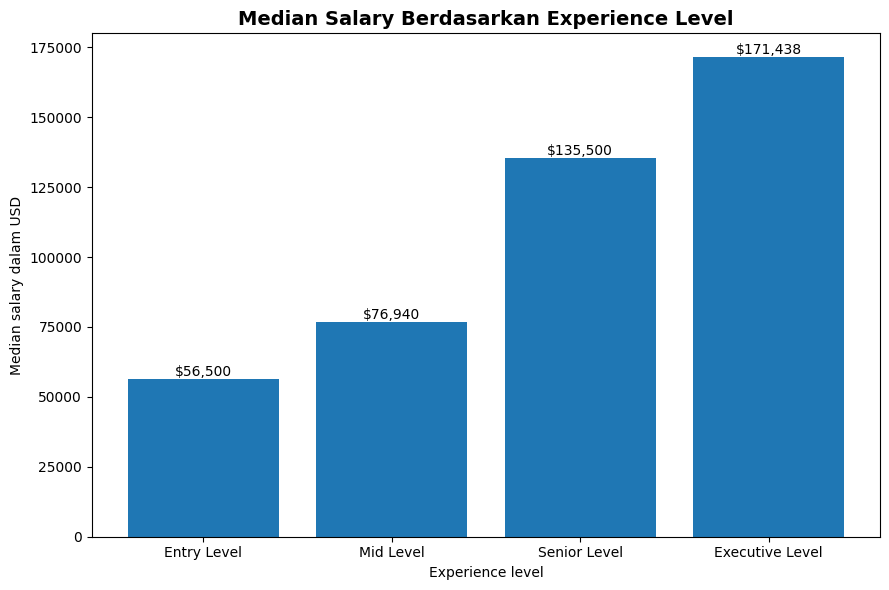


Visualisasi 2: Distribusi salary berdasarkan experience level


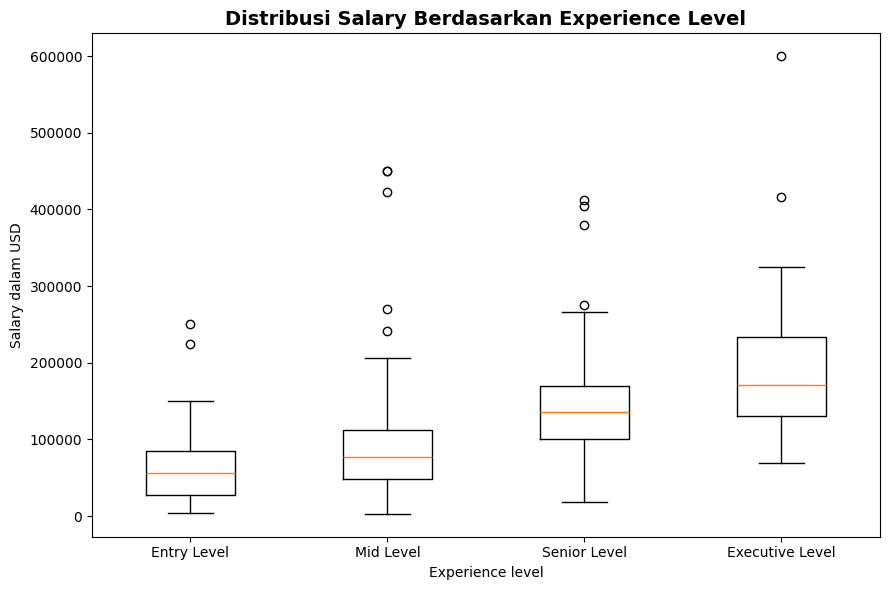


Kenaikan median salary antar experience level


,experience_label,median_salary,previous_median_salary,salary_increase,salary_increase_percentage
0,Entry Level,56500.0,NaN,NaN,NaN
1,Mid Level,76940.0,56500.0,20440.0,36.18
2,Senior Level,135500.0,76940.0,58560.0,76.11
3,Executive Level,171438.0,135500.0,35938.0,26.52



Fokus Data Analyst: Salary berdasarkan experience level


,experience_label,total_data,median_salary,average_salary,min_salary,max_salary
0,Entry Level,17,59102.0,57112.0,6072,100000
1,Mid Level,41,65438.0,77941.0,6072,450000
2,Senior Level,58,111912.0,112662.0,60000,200000
3,Executive Level,3,130000.0,130000.0,110000,150000



Visualisasi 3: Median salary Data Analyst berdasarkan experience level


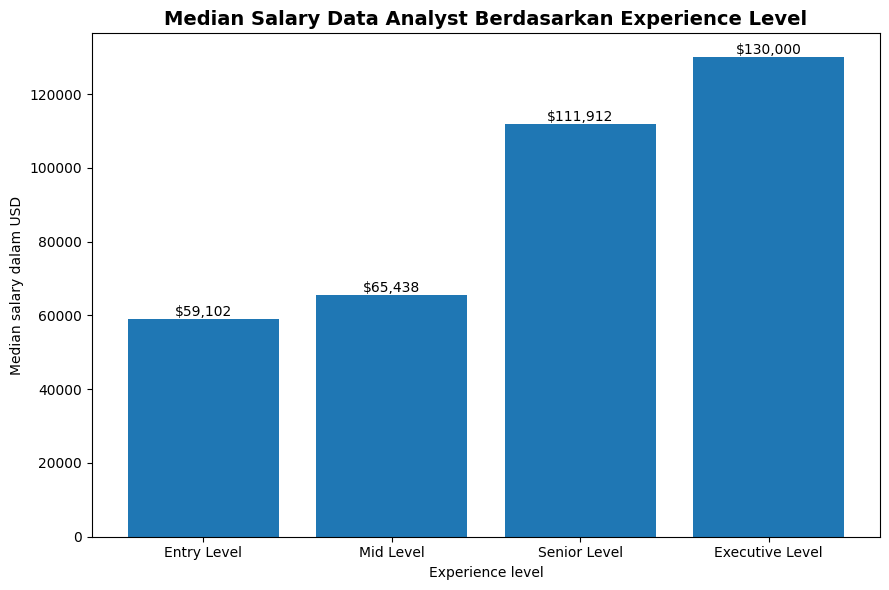

In [14]:
# Pengaruh experience level terhadap salary

experience_order = [
    "Entry Level",
    "Mid Level",
    "Senior Level",
    "Executive Level"
]

salary_by_experience = (
    df_salary
    .groupby("experience_label")
    .agg(
        total_data=("salary_in_usd", "count"),
        median_salary=("salary_in_usd", "median"),
        average_salary=("salary_in_usd", "mean"),
        min_salary=("salary_in_usd", "min"),
        max_salary=("salary_in_usd", "max")
    )
    .reindex(experience_order)
    .reset_index()
)

salary_by_experience["median_salary"] = salary_by_experience["median_salary"].round(0)
salary_by_experience["average_salary"] = salary_by_experience["average_salary"].round(0)

print("=" * 85)
print("Ringkasan salary berdasarkan experience level")
print("=" * 85)

display(salary_by_experience)


print("\n" + "=" * 85)
print("Visualisasi 1: Median salary berdasarkan experience level")
print("=" * 85)

plt.figure(figsize=(9, 6))

plt.bar(
    salary_by_experience["experience_label"],
    salary_by_experience["median_salary"]
)

plt.title("Median Salary Berdasarkan Experience Level", fontsize=14, fontweight="bold")
plt.xlabel("Experience level")
plt.ylabel("Median salary dalam USD")

for index, value in enumerate(salary_by_experience["median_salary"]):
    plt.text(index, value, f"${value:,.0f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()


print("\n" + "=" * 85)
print("Visualisasi 2: Distribusi salary berdasarkan experience level")
print("=" * 85)

salary_distribution_exp = [
    df_salary[df_salary["experience_label"] == exp]["salary_in_usd"]
    for exp in experience_order
]

plt.figure(figsize=(9, 6))

plt.boxplot(
    salary_distribution_exp,
    tick_labels=experience_order,
    vert=True
)

plt.title("Distribusi Salary Berdasarkan Experience Level", fontsize=14, fontweight="bold")
plt.xlabel("Experience level")
plt.ylabel("Salary dalam USD")

plt.tight_layout()
plt.show()


print("\n" + "=" * 85)
print("Kenaikan median salary antar experience level")
print("=" * 85)

salary_growth = salary_by_experience[["experience_label", "median_salary"]].copy()
salary_growth["previous_median_salary"] = salary_growth["median_salary"].shift(1)

salary_growth["salary_increase"] = (
    salary_growth["median_salary"] - salary_growth["previous_median_salary"]
)

salary_growth["salary_increase_percentage"] = (
    salary_growth["salary_increase"] / salary_growth["previous_median_salary"] * 100
).round(2)

display(salary_growth)


print("\n" + "=" * 85)
print("Fokus Data Analyst: Salary berdasarkan experience level")
print("=" * 85)

da_salary_experience = (
    df_salary[df_salary["role_group"] == "Data Analyst"]
    .groupby("experience_label")
    .agg(
        total_data=("salary_in_usd", "count"),
        median_salary=("salary_in_usd", "median"),
        average_salary=("salary_in_usd", "mean"),
        min_salary=("salary_in_usd", "min"),
        max_salary=("salary_in_usd", "max")
    )
    .reindex(experience_order)
    .reset_index()
)

da_salary_experience["median_salary"] = da_salary_experience["median_salary"].round(0)
da_salary_experience["average_salary"] = da_salary_experience["average_salary"].round(0)

display(da_salary_experience)


print("\n" + "=" * 85)
print("Visualisasi 3: Median salary Data Analyst berdasarkan experience level")
print("=" * 85)

da_plot = da_salary_experience.dropna(subset=["median_salary"]).copy()

plt.figure(figsize=(9, 6))

plt.bar(
    da_plot["experience_label"],
    da_plot["median_salary"]
)

plt.title("Median Salary Data Analyst Berdasarkan Experience Level", fontsize=14, fontweight="bold")
plt.xlabel("Experience level")
plt.ylabel("Median salary dalam USD")

for index, value in enumerate(da_plot["median_salary"]):
    plt.text(index, value, f"${value:,.0f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

Ringkasan salary berdasarkan tipe kerja


,remote_label,total_data,median_salary,average_salary,min_salary,max_salary
0,On-site,127,99000.0,106355.0,2859,450000
1,Hybrid,99,69999.0,80823.0,5409,423000
2,Fully Remote,381,115000.0,122457.0,4000,600000



Visualisasi 1: Median salary berdasarkan tipe kerja


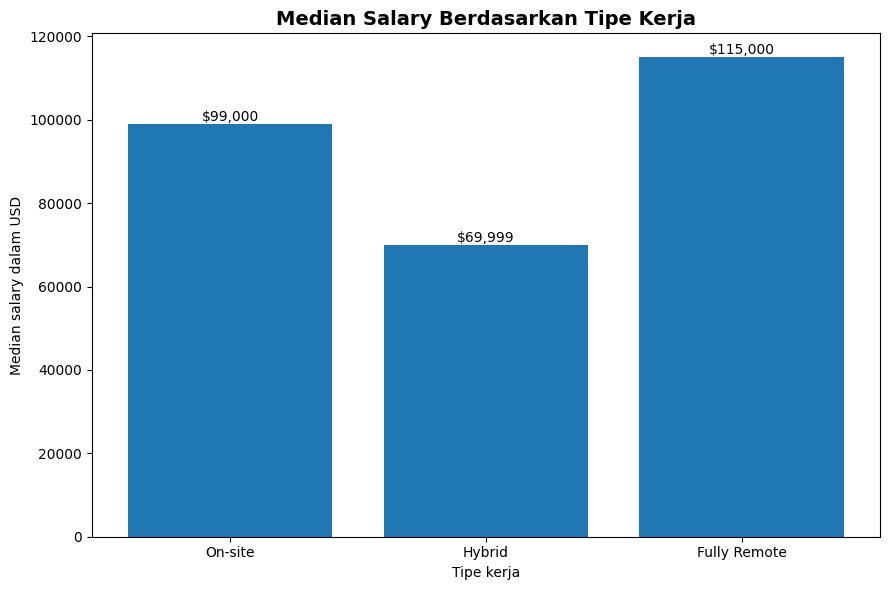


Visualisasi 2: Distribusi salary berdasarkan tipe kerja


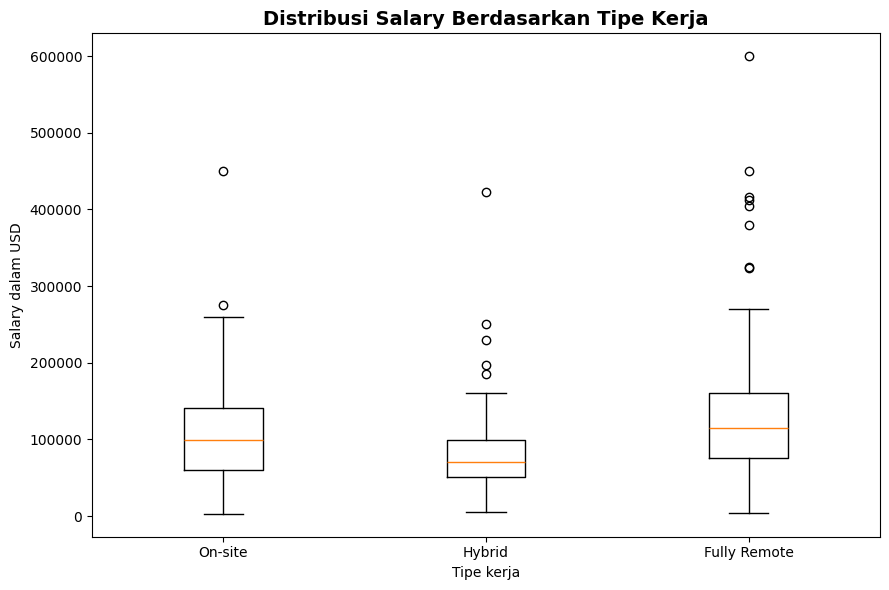


Fokus Data Analyst: Salary berdasarkan tipe kerja


,remote_label,total_data,median_salary,average_salary,min_salary,max_salary
0,On-site,23,81666.0,84203.0,6072,164000
1,Hybrid,11,55000.0,51239.0,8000,100000
2,Fully Remote,85,99050.0,101065.0,6072,450000



Visualisasi 3: Median salary Data Analyst berdasarkan tipe kerja


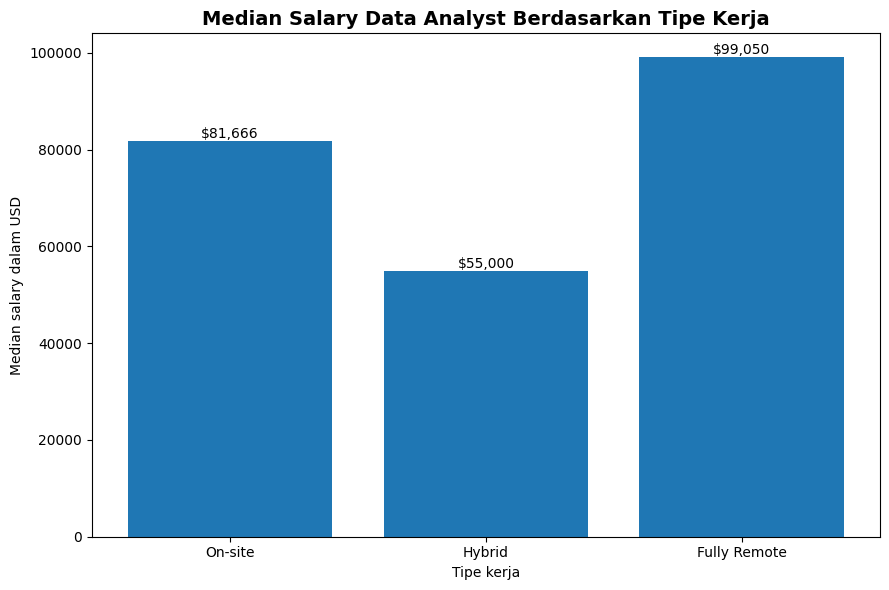


Tambahan: Tipe kerja berdasarkan experience level


,experience_label,remote_label,total_data,median_salary
2,Entry Level,On-site,14,51660.0
1,Entry Level,Hybrid,25,55000.0
0,Entry Level,Fully Remote,49,59102.0
8,Mid Level,On-site,56,74000.0
7,Mid Level,Hybrid,42,63218.0
6,Mid Level,Fully Remote,115,87000.0
11,Senior Level,On-site,54,138200.0
10,Senior Level,Hybrid,27,94665.0
9,Senior Level,Fully Remote,199,140000.0
5,Executive Level,On-site,3,141846.0



Visualisasi 4: Median salary tipe kerja berdasarkan experience level


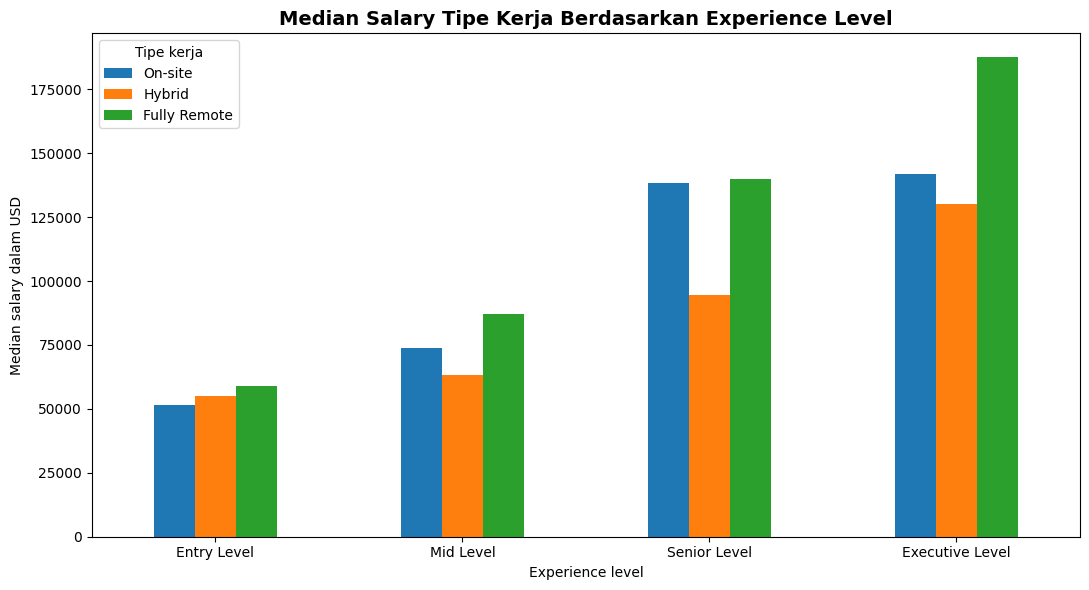

In [15]:
# Pengaruh remote work terhadap salary

remote_order = [
    "On-site",
    "Hybrid",
    "Fully Remote"
]

salary_by_remote = (
    df_salary
    .groupby("remote_label")
    .agg(
        total_data=("salary_in_usd", "count"),
        median_salary=("salary_in_usd", "median"),
        average_salary=("salary_in_usd", "mean"),
        min_salary=("salary_in_usd", "min"),
        max_salary=("salary_in_usd", "max")
    )
    .reindex(remote_order)
    .reset_index()
)

salary_by_remote["median_salary"] = salary_by_remote["median_salary"].round(0)
salary_by_remote["average_salary"] = salary_by_remote["average_salary"].round(0)

print("=" * 85)
print("Ringkasan salary berdasarkan tipe kerja")
print("=" * 85)

display(salary_by_remote)


print("\n" + "=" * 85)
print("Visualisasi 1: Median salary berdasarkan tipe kerja")
print("=" * 85)

plt.figure(figsize=(9, 6))

plt.bar(
    salary_by_remote["remote_label"],
    salary_by_remote["median_salary"]
)

plt.title("Median Salary Berdasarkan Tipe Kerja", fontsize=14, fontweight="bold")
plt.xlabel("Tipe kerja")
plt.ylabel("Median salary dalam USD")

for index, value in enumerate(salary_by_remote["median_salary"]):
    plt.text(index, value, f"${value:,.0f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()


print("\n" + "=" * 85)
print("Visualisasi 2: Distribusi salary berdasarkan tipe kerja")
print("=" * 85)

salary_distribution_remote = [
    df_salary[df_salary["remote_label"] == remote]["salary_in_usd"]
    for remote in remote_order
]

plt.figure(figsize=(9, 6))

plt.boxplot(
    salary_distribution_remote,
    tick_labels=remote_order,
    vert=True
)

plt.title("Distribusi Salary Berdasarkan Tipe Kerja", fontsize=14, fontweight="bold")
plt.xlabel("Tipe kerja")
plt.ylabel("Salary dalam USD")

plt.tight_layout()
plt.show()


print("\n" + "=" * 85)
print("Fokus Data Analyst: Salary berdasarkan tipe kerja")
print("=" * 85)

da_salary_remote = (
    df_salary[df_salary["role_group"] == "Data Analyst"]
    .groupby("remote_label")
    .agg(
        total_data=("salary_in_usd", "count"),
        median_salary=("salary_in_usd", "median"),
        average_salary=("salary_in_usd", "mean"),
        min_salary=("salary_in_usd", "min"),
        max_salary=("salary_in_usd", "max")
    )
    .reindex(remote_order)
    .reset_index()
)

da_salary_remote["median_salary"] = da_salary_remote["median_salary"].round(0)
da_salary_remote["average_salary"] = da_salary_remote["average_salary"].round(0)

display(da_salary_remote)


print("\n" + "=" * 85)
print("Visualisasi 3: Median salary Data Analyst berdasarkan tipe kerja")
print("=" * 85)

da_remote_plot = da_salary_remote.dropna(subset=["median_salary"]).copy()

plt.figure(figsize=(9, 6))

plt.bar(
    da_remote_plot["remote_label"],
    da_remote_plot["median_salary"]
)

plt.title("Median Salary Data Analyst Berdasarkan Tipe Kerja", fontsize=14, fontweight="bold")
plt.xlabel("Tipe kerja")
plt.ylabel("Median salary dalam USD")

for index, value in enumerate(da_remote_plot["median_salary"]):
    plt.text(index, value, f"${value:,.0f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()


print("\n" + "=" * 85)
print("Tambahan: Tipe kerja berdasarkan experience level")
print("=" * 85)

remote_experience_summary = (
    df_salary
    .groupby(["experience_label", "remote_label"])
    .agg(
        total_data=("salary_in_usd", "count"),
        median_salary=("salary_in_usd", "median")
    )
    .reset_index()
)

remote_experience_summary["experience_label"] = pd.Categorical(
    remote_experience_summary["experience_label"],
    categories=experience_order,
    ordered=True
)

remote_experience_summary["remote_label"] = pd.Categorical(
    remote_experience_summary["remote_label"],
    categories=remote_order,
    ordered=True
)

remote_experience_summary = remote_experience_summary.sort_values(
    ["experience_label", "remote_label"]
)

remote_experience_summary["median_salary"] = remote_experience_summary["median_salary"].round(0)

display(remote_experience_summary)


print("\n" + "=" * 85)
print("Visualisasi 4: Median salary tipe kerja berdasarkan experience level")
print("=" * 85)

remote_exp_pivot = remote_experience_summary.pivot(
    index="experience_label",
    columns="remote_label",
    values="median_salary"
).reindex(experience_order)

remote_exp_pivot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Median Salary Tipe Kerja Berdasarkan Experience Level", fontsize=14, fontweight="bold")
plt.xlabel("Experience level")
plt.ylabel("Median salary dalam USD")
plt.xticks(rotation=0)
plt.legend(title="Tipe kerja")

plt.tight_layout()
plt.show()

Jumlah data berdasarkan negara perusahaan


,company_country,total_data
48,United States,355
47,United Kingdom,47
6,Canada,30
14,Germany,28
20,India,24
13,France,15
42,Spain,14
15,Greece,11
25,Japan,6
3,Austria,4



Negara dengan median salary tertinggi, minimal 5 data


,company_country,total_data,median_salary,average_salary,min_salary,max_salary
48,United States,355,135000.0,144055.0,5679,600000
6,Canada,30,81896.0,99824.0,52000,225000
47,United Kingdom,47,78526.0,81583.0,37300,183228
14,Germany,28,78015.0,81887.0,15966,173762
25,Japan,6,75682.0,114127.0,41689,260000
13,France,15,56738.0,63971.0,36643,152000
15,Greece,11,49461.0,52293.0,20000,87932
42,Spain,14,48372.0,53060.0,10354,87932
20,India,24,22124.0,28582.0,5409,94665



Visualisasi 1: Negara dengan median salary tertinggi


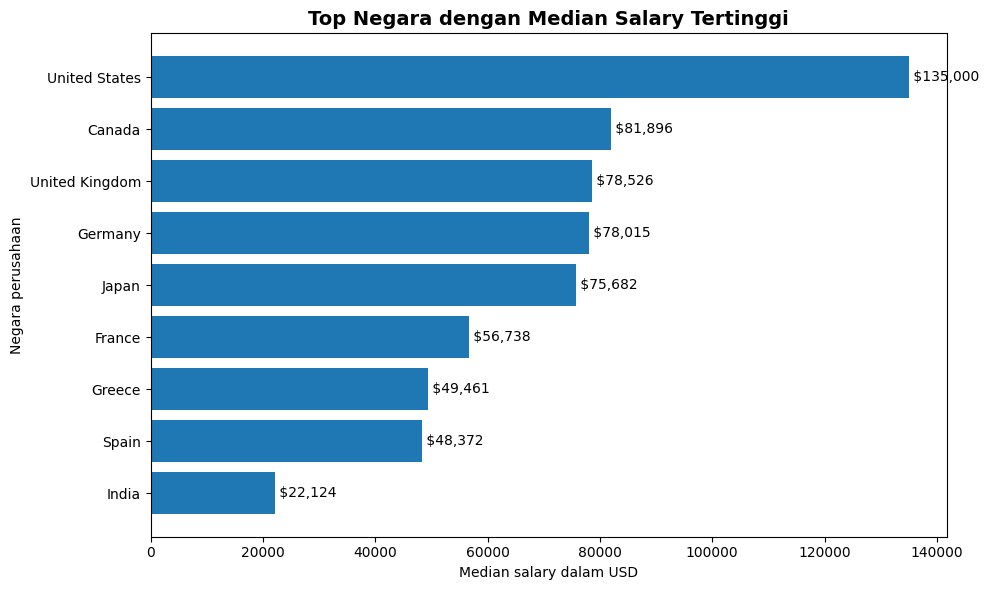


Visualisasi 2: Jumlah data job berdasarkan negara perusahaan


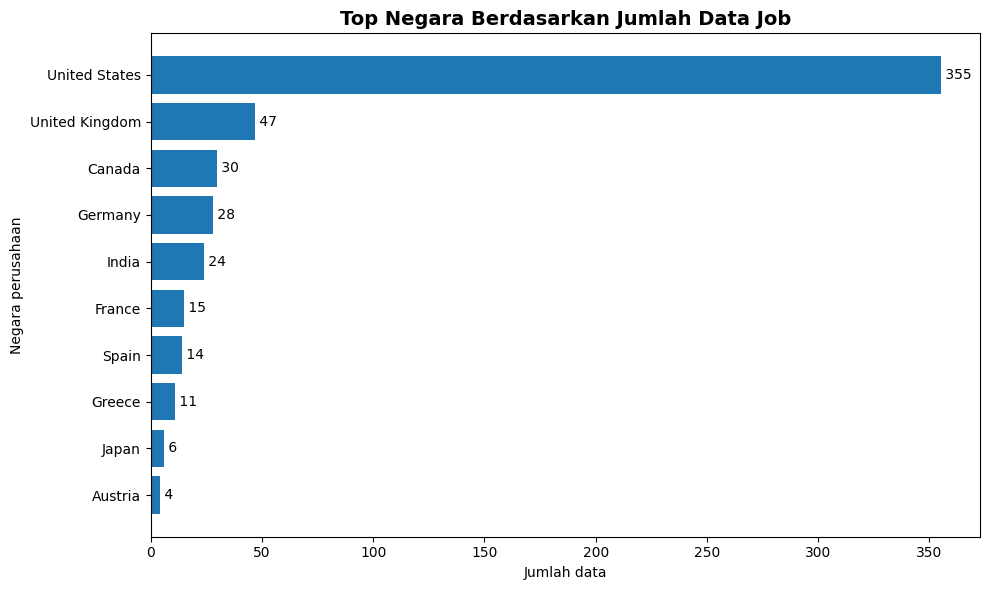


Fokus Data Analyst: Negara dengan kompensasi tertinggi


,company_country,total_data,median_salary,average_salary,min_salary,max_salary
13,United States,83,105000.0,112001.0,36259,450000
0,Canada,11,71786.0,79936.0,52000,130000
12,United Kingdom,6,51935.0,52712.0,39263,65438
4,Greece,3,32974.0,32313.0,20000,43966
11,Spain,3,32974.0,29098.0,10354,43966
6,India,4,12257.0,12549.0,6072,19609



Visualisasi 3: Median salary Data Analyst berdasarkan negara perusahaan


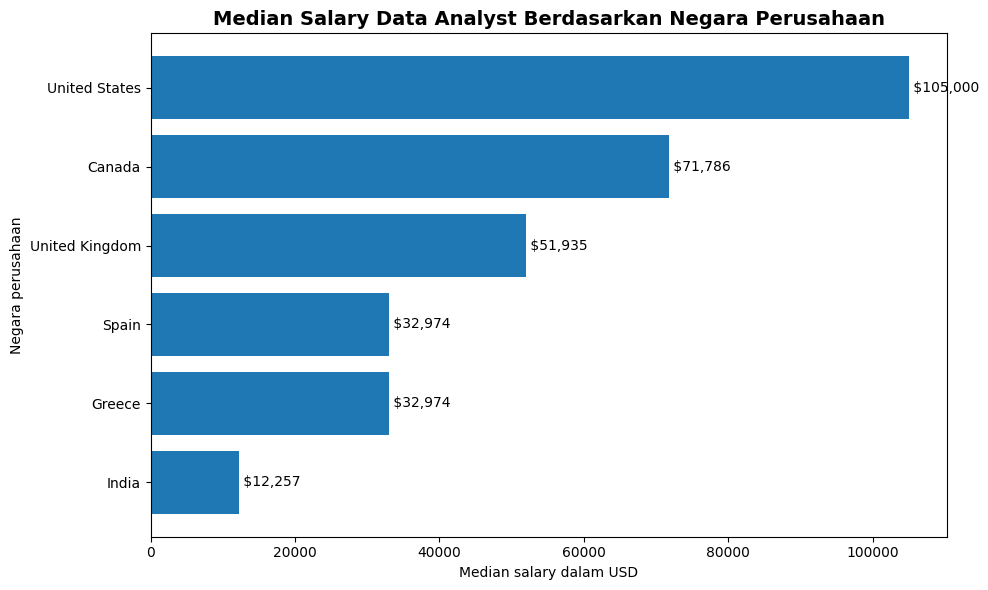

In [16]:
# Negara dengan kompensasi tertinggi

# Mapping kode negara supaya lebih mudah dibaca
country_map = {
    "US": "United States",
    "GB": "United Kingdom",
    "CA": "Canada",
    "DE": "Germany",
    "IN": "India",
    "FR": "France",
    "ES": "Spain",
    "GR": "Greece",
    "JP": "Japan",
    "NL": "Netherlands",
    "AT": "Austria",
    "PT": "Portugal",
    "PL": "Poland",
    "PK": "Pakistan",
    "BR": "Brazil",
    "AU": "Australia",
    "TR": "Turkey",
    "DK": "Denmark",
    "MX": "Mexico",
    "NG": "Nigeria",
    "CN": "China",
    "RU": "Russia",
    "IT": "Italy",
    "CH": "Switzerland",
    "AE": "United Arab Emirates",
    "SG": "Singapore",
    "BE": "Belgium",
    "LU": "Luxembourg",
    "SI": "Slovenia",
    "RO": "Romania",
    "VN": "Vietnam",
    "CL": "Chile",
    "HU": "Hungary",
    "EE": "Estonia",
    "CZ": "Czech Republic",
    "DZ": "Algeria",
    "MY": "Malaysia",
    "HN": "Honduras",
    "NZ": "New Zealand",
    "IE": "Ireland",
    "MT": "Malta",
    "UA": "Ukraine",
    "IQ": "Iraq",
    "IR": "Iran",
    "CO": "Colombia",
    "KE": "Kenya",
    "MD": "Moldova",
    "AS": "American Samoa"
}

df_salary["company_country"] = df_salary["company_location"].map(country_map).fillna(df_salary["company_location"])
df_salary["employee_country"] = df_salary["employee_residence"].map(country_map).fillna(df_salary["employee_residence"])


print("=" * 85)
print("Jumlah data berdasarkan negara perusahaan")
print("=" * 85)

country_count = (
    df_salary
    .groupby("company_country")
    .size()
    .reset_index(name="total_data")
    .sort_values("total_data", ascending=False)
)

display(country_count.head(20))


# Ringkasan salary per negara perusahaan
country_salary = (
    df_salary
    .groupby("company_country")
    .agg(
        total_data=("salary_in_usd", "count"),
        median_salary=("salary_in_usd", "median"),
        average_salary=("salary_in_usd", "mean"),
        min_salary=("salary_in_usd", "min"),
        max_salary=("salary_in_usd", "max")
    )
    .reset_index()
)

country_salary["median_salary"] = country_salary["median_salary"].round(0)
country_salary["average_salary"] = country_salary["average_salary"].round(0)

# Filter negara dengan jumlah data cukup
min_country_data = 5

country_salary_filtered = (
    country_salary[country_salary["total_data"] >= min_country_data]
    .sort_values("median_salary", ascending=False)
    .copy()
)

print("\n" + "=" * 85)
print(f"Negara dengan median salary tertinggi, minimal {min_country_data} data")
print("=" * 85)

display(country_salary_filtered.head(15))


print("\n" + "=" * 85)
print("Visualisasi 1: Negara dengan median salary tertinggi")
print("=" * 85)

top_country_salary = country_salary_filtered.head(10).sort_values("median_salary", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    top_country_salary["company_country"],
    top_country_salary["median_salary"]
)

plt.title("Top Negara dengan Median Salary Tertinggi", fontsize=14, fontweight="bold")
plt.xlabel("Median salary dalam USD")
plt.ylabel("Negara perusahaan")

for index, value in enumerate(top_country_salary["median_salary"]):
    plt.text(value, index, f" ${value:,.0f}", va="center")

plt.tight_layout()
plt.show()


print("\n" + "=" * 85)
print("Visualisasi 2: Jumlah data job berdasarkan negara perusahaan")
print("=" * 85)

top_country_count = country_count.head(10).sort_values("total_data", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    top_country_count["company_country"],
    top_country_count["total_data"]
)

plt.title("Top Negara Berdasarkan Jumlah Data Job", fontsize=14, fontweight="bold")
plt.xlabel("Jumlah data")
plt.ylabel("Negara perusahaan")

for index, value in enumerate(top_country_count["total_data"]):
    plt.text(value, index, f" {value}", va="center")

plt.tight_layout()
plt.show()


print("\n" + "=" * 85)
print("Fokus Data Analyst: Negara dengan kompensasi tertinggi")
print("=" * 85)

da_country_salary = (
    df_salary[df_salary["role_group"] == "Data Analyst"]
    .groupby("company_country")
    .agg(
        total_data=("salary_in_usd", "count"),
        median_salary=("salary_in_usd", "median"),
        average_salary=("salary_in_usd", "mean"),
        min_salary=("salary_in_usd", "min"),
        max_salary=("salary_in_usd", "max")
    )
    .reset_index()
)

da_country_salary["median_salary"] = da_country_salary["median_salary"].round(0)
da_country_salary["average_salary"] = da_country_salary["average_salary"].round(0)

min_da_country_data = 3

da_country_salary_filtered = (
    da_country_salary[da_country_salary["total_data"] >= min_da_country_data]
    .sort_values("median_salary", ascending=False)
    .copy()
)

display(da_country_salary_filtered.head(10))


print("\n" + "=" * 85)
print("Visualisasi 3: Median salary Data Analyst berdasarkan negara perusahaan")
print("=" * 85)

da_country_plot = da_country_salary_filtered.head(10).sort_values("median_salary", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    da_country_plot["company_country"],
    da_country_plot["median_salary"]
)

plt.title("Median Salary Data Analyst Berdasarkan Negara Perusahaan", fontsize=14, fontweight="bold")
plt.xlabel("Median salary dalam USD")
plt.ylabel("Negara perusahaan")

for index, value in enumerate(da_country_plot["median_salary"]):
    plt.text(value, index, f" ${value:,.0f}", va="center")

plt.tight_layout()
plt.show()

Opportunity Score berdasarkan demand, salary, dan remote availability


,role_group,total_data,median_salary,fully_remote_jobs,remote_percentage,demand_score,salary_score,remote_score,opportunity_score
0,Data Scientist,175,104890.0,94,53.71,100.00,58.27,53.71,74.05
1,Data Engineer,160,107400.0,108,67.50,91.43,59.67,67.50,73.94
2,Data Architect,11,180000.0,11,100.00,6.29,100.00,100.00,62.51
3,Data Analyst,119,90320.0,85,71.43,68.00,50.18,71.43,61.56
4,Data Science Management,33,141846.0,19,57.58,18.86,78.80,57.58,50.58
5,Machine Learning / AI,75,87425.0,41,54.67,42.86,48.57,54.67,47.50
6,Analytics / BI,17,120000.0,12,70.59,9.71,66.67,70.59,44.67
7,Other Data Role,17,70000.0,11,64.71,9.71,38.89,64.71,32.38



Visualisasi 1: Ranking Opportunity Score


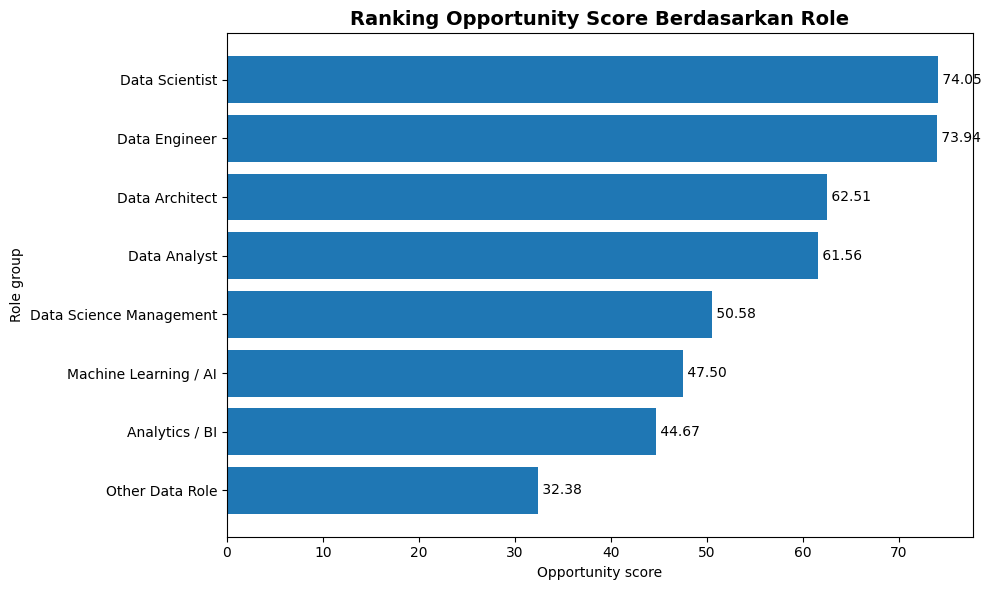


Visualisasi 2: Demand vs Salary dengan ukuran bubble remote availability


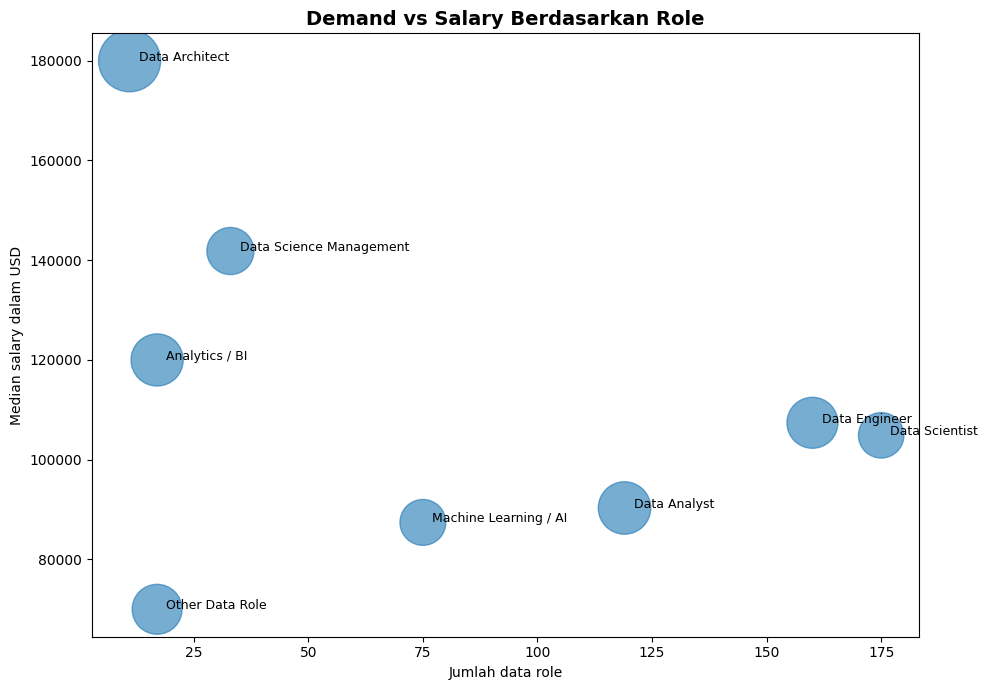


Rekomendasi karier berdasarkan hasil Opportunity Score
Role dengan opportunity score tertinggi: Data Scientist
Opportunity score: 74.05
Jumlah data: 175
Median salary: $104,890
Fully remote: 53.71%


In [17]:
# Opportunity Score untuk rekomendasi karier

role_opportunity = (
    df_salary
    .groupby("role_group")
    .agg(
        total_data=("salary_in_usd", "count"),
        median_salary=("salary_in_usd", "median"),
        average_salary=("salary_in_usd", "mean"),
        fully_remote_jobs=("remote_label", lambda x: (x == "Fully Remote").sum())
    )
    .reset_index()
)

role_opportunity["remote_percentage"] = (
    role_opportunity["fully_remote_jobs"] / role_opportunity["total_data"] * 100
)

# Filter role yang jumlah datanya cukup supaya ranking tidak terlalu bias
min_role_data = 10

role_opportunity = role_opportunity[
    role_opportunity["total_data"] >= min_role_data
].copy()

# Normalisasi manual ke skala 0-100
role_opportunity["demand_score"] = (
    role_opportunity["total_data"] / role_opportunity["total_data"].max() * 100
)

role_opportunity["salary_score"] = (
    role_opportunity["median_salary"] / role_opportunity["median_salary"].max() * 100
)

role_opportunity["remote_score"] = (
    role_opportunity["remote_percentage"] / role_opportunity["remote_percentage"].max() * 100
)

# Bobot skor
role_opportunity["opportunity_score"] = (
    0.4 * role_opportunity["demand_score"] +
    0.4 * role_opportunity["salary_score"] +
    0.2 * role_opportunity["remote_score"]
)

# Rapihin angka
columns_to_round = [
    "median_salary",
    "average_salary",
    "remote_percentage",
    "demand_score",
    "salary_score",
    "remote_score",
    "opportunity_score"
]

role_opportunity[columns_to_round] = role_opportunity[columns_to_round].round(2)

role_opportunity = role_opportunity.sort_values(
    "opportunity_score",
    ascending=False
).reset_index(drop=True)

print("=" * 90)
print("Opportunity Score berdasarkan demand, salary, dan remote availability")
print("=" * 90)

display(
    role_opportunity[
        [
            "role_group",
            "total_data",
            "median_salary",
            "fully_remote_jobs",
            "remote_percentage",
            "demand_score",
            "salary_score",
            "remote_score",
            "opportunity_score"
        ]
    ]
)


print("\n" + "=" * 90)
print("Visualisasi 1: Ranking Opportunity Score")
print("=" * 90)

plot_opportunity = role_opportunity.sort_values("opportunity_score", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_opportunity["role_group"],
    plot_opportunity["opportunity_score"]
)

plt.title("Ranking Opportunity Score Berdasarkan Role", fontsize=14, fontweight="bold")
plt.xlabel("Opportunity score")
plt.ylabel("Role group")

for index, value in enumerate(plot_opportunity["opportunity_score"]):
    plt.text(value, index, f" {value:.2f}", va="center")

plt.tight_layout()
plt.show()


print("\n" + "=" * 90)
print("Visualisasi 2: Demand vs Salary dengan ukuran bubble remote availability")
print("=" * 90)

plt.figure(figsize=(10, 7))

plt.scatter(
    role_opportunity["total_data"],
    role_opportunity["median_salary"],
    s=role_opportunity["remote_percentage"] * 20,
    alpha=0.6
)

plt.title("Demand vs Salary Berdasarkan Role", fontsize=14, fontweight="bold")
plt.xlabel("Jumlah data role")
plt.ylabel("Median salary dalam USD")

for _, row in role_opportunity.iterrows():
    plt.text(
        row["total_data"] + 2,
        row["median_salary"],
        row["role_group"],
        fontsize=9
    )

plt.tight_layout()
plt.show()


print("\n" + "=" * 90)
print("Rekomendasi karier berdasarkan hasil Opportunity Score")
print("=" * 90)

top_role = role_opportunity.iloc[0]

print(f"Role dengan opportunity score tertinggi: {top_role['role_group']}")
print(f"Opportunity score: {top_role['opportunity_score']}")
print(f"Jumlah data: {int(top_role['total_data'])}")
print(f"Median salary: ${top_role['median_salary']:,.0f}")
print(f"Fully remote: {top_role['remote_percentage']:.2f}%")